In [2]:
import pandas as pd
import numpy as np
import graphviz
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats
import warnings

from statsmodels.formula.api import ols
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot, add_constant
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 환경에서는 'Malgun Gothic' 폰트를 사용
else:
    plt.rcParams['font.family'] = 'AppleGothic'  # macOS나 Linux 등 다른 환경에서는 'AppleGothic' 폰트를 사용

matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
#데이터 불러오기
df_1= pd.read_csv(r"C:\Users\김어진\OneDrive\바탕 화면\빅데이터분석\sts_1sm_cc_1.csv", encoding = 'euc-kr')
df_2= pd.read_csv(r"C:\Users\김어진\OneDrive\바탕 화면\빅데이터분석\sts_2fur_hr_2.csv", encoding = 'euc-kr')
df_3= pd.read_csv(r"C:\Users\김어진\OneDrive\바탕 화면\빅데이터분석\sts_3ap_3.csv", encoding = 'euc-kr')

In [4]:
df_1.isnull().sum()

sm_plant         0
charge_id        0
steel_grade      0
steel_usage      0
delta_ferrite    0
ingre_cr         0
ingre_ni         0
ingre_s          0
cast_date        0
cc_gubun         0
tundish_temp     2
mlac_ratio       3
slab_no          0
slab_gubun       0
slab_grind       9
dtype: int64

In [5]:
df_2.isnull().sum()

charge_id          0
slab_no            0
furnace_no         0
f_jangip_gubun     0
f_jangip_temp      0
f_bfg              1
f_cog              2
f_ldg              0
f_bfg_per          1
f_cog_per          1
f_ldg_per          0
f_pre_temp         3
f_heat_temp        0
f_sock_temp        2
f_pre_interval     0
f_heat_interval    0
f_sock_interval    3
f_ext_date         0
f_ext_time         0
hr_coil_id         0
hr_date            0
hr_thick           0
hr_width           0
rm4_temp           0
rm_pitch           0
slab_width         0
dtype: int64

In [6]:
df_3.isnull().sum()

judge            0
hr_coil_id       0
ap_plant         0
ap_prod_id       2
ap_date          0
ap_shift         0
ap_thick         0
ap_width         1
ap_line_speed    3
dtype: int64

In [7]:
null_rows = df_1[df_1['slab_grind'].isnull()]

# 결과 확인
null_rows

,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
14,1공장,CH80156,C13,RJ1,78,18.57,8.24,0.02,2025-07-13,2연주,1488.0,98.7,111,M,NaN
15,1공장,CH80156,C13,RJ1,78,18.57,8.24,0.02,2025-07-13,2연주,1488.0,NaN,211,M,NaN
16,1공장,CH80156,C13,RJ1,75,18.57,8.24,0.02,2025-07-13,2연주,0.0,98.7,311,M,NaN
39,1공장,CH80164,C13,Other,73,18.39,8.30,0.03,2025-07-13,2연주,520.0,97.5,611,C,NaN
239,1공장,CH80441,C13,RJ1,74,18.50,8.27,0.06,2025-07-30,2연주,NaN,0.0,211,C,NaN
240,1공장,CH80441,C13,RJ1,74,18.50,8.27,0.06,2025-07-30,2연주,1491.0,NaN,311,C,NaN
241,1공장,CH80441,C13,RJ1,74,18.50,8.27,0.06,2025-07-30,2연주,1491.0,120.0,411,C,NaN
1786,1공장,CH81002,C13,RJ1,69,18.27,8.24,0.06,2025-07-24,2연주,1484.0,0.0,311,C,NaN
1787,1공장,CH81002,C13,RJ1,69,18.27,8.24,0.06,2025-07-24,2연주,821.0,99.5,411,C,NaN


In [8]:
outlier = df_2[(df_2['slab_no'] == 411) & (df_2['charge_id'] == 'CH80441')]
outlier

,charge_id,slab_no,furnace_no,f_jangip_gubun,f_jangip_temp,f_bfg,f_cog,f_ldg,f_bfg_per,f_cog_per,...,f_sock_interval,f_ext_date,f_ext_time,hr_coil_id,hr_date,hr_thick,hr_width,rm4_temp,rm_pitch,slab_width


In [9]:
outlier = df_3[(df_3['hr_coil_id'] == 'U687944')]
outlier

,judge,hr_coil_id,ap_plant,ap_prod_id,ap_date,ap_shift,ap_thick,ap_width,ap_line_speed
12392,양품,U687944,2공장,X89724,2025-08-07,B,2.98,1222.0,47.0


In [10]:
df_1.dropna(inplace=True)
df_2.dropna(inplace=True)
df_3.dropna(inplace=True)

In [11]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 연속형 변수만 선택
# cols = ['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s']

# plt.figure(figsize=(12,6))
# df_cc_1[cols].boxplot()
# plt.title('Boxplot of Continuous Variables')
# plt.show()

In [12]:
# cols = ['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s']

# for col in cols:
#     plt.figure(figsize=(6,4))
#     sns.boxplot(y=df_cc_1[col])
#     plt.title(f'{col} Boxplot')
#     plt.show()

In [13]:
# from scipy import stats
# import numpy as np

# cols = ['delta_ferrite','ingre_cr','ingre_ni','ingre_s']

# z_scores = np.abs(stats.zscore(df_cc_1[cols]))

# # threshold = 3 (보통 기준)
# outliers = (z_scores > 3)

# df_1[outliers.any(axis=1)]

In [14]:
# import matplotlib.pyplot as plt

# for col in cols:
#     plt.figure(figsize=(5,3))
#     plt.hist(df_cc_1[col], bins=30)
#     plt.title(col)
#     plt.show()

## 이상치 제거

In [15]:
print(df_1.columns)
print(df_2.columns)
print(df_3.columns)

print(len(df_2))


Index(['sm_plant', 'charge_id', 'steel_grade', 'steel_usage', 'delta_ferrite',
       'ingre_cr', 'ingre_ni', 'ingre_s', 'cast_date', 'cc_gubun',
       'tundish_temp', 'mlac_ratio', 'slab_no', 'slab_gubun', 'slab_grind'],
      dtype='object')
Index(['charge_id', 'slab_no', 'furnace_no', 'f_jangip_gubun', 'f_jangip_temp',
       'f_bfg', 'f_cog', 'f_ldg', 'f_bfg_per', 'f_cog_per', 'f_ldg_per',
       'f_pre_temp', 'f_heat_temp', 'f_sock_temp', 'f_pre_interval',
       'f_heat_interval', 'f_sock_interval', 'f_ext_date', 'f_ext_time',
       'hr_coil_id', 'hr_date', 'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
       'slab_width'],
      dtype='object')
Index(['judge', 'hr_coil_id', 'ap_plant', 'ap_prod_id', 'ap_date', 'ap_shift',
       'ap_thick', 'ap_width', 'ap_line_speed'],
      dtype='object')
23643


In [16]:
df_2= df_2[df_2['f_sock_temp']<1400]
df_2= df_2[df_2['f_sock_temp']>200]

<Axes: ylabel='f_sock_temp'>

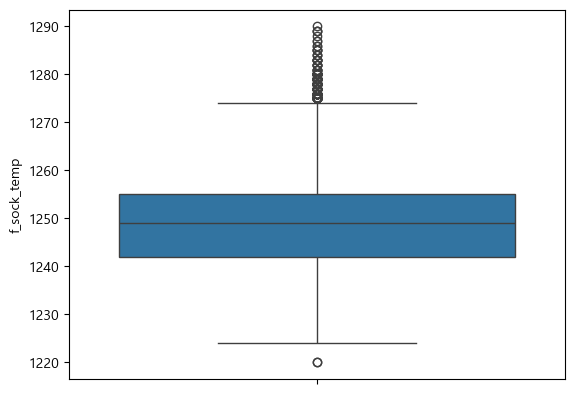

In [17]:
sns.boxplot(y=df_2['f_sock_temp'])

<Axes: ylabel='f_sock_interval'>

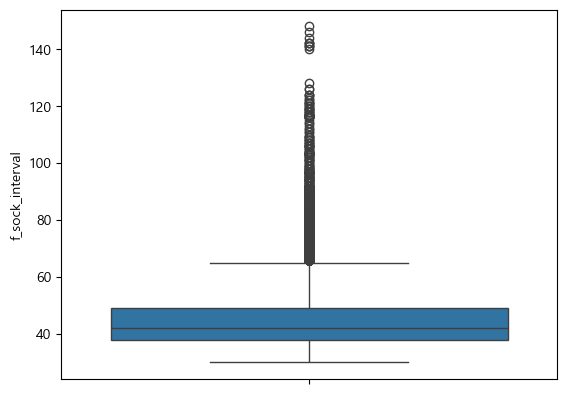

In [18]:
df_2= df_2[df_2['f_sock_interval']!=168]
sns.boxplot(y=df_2['f_sock_interval'])

In [19]:
df_2['hr_thick_group'] = np.select(
[
df_2['hr_thick'] <= 3.46,
(df_2['hr_thick'] >= 3.46) & (df_2['hr_thick'] <= 4.48),
df_2['hr_thick'] >= 4.48
],
[
'얇음(<=3.46)',
'중간(3.46~4.48)',
'두꺼움(>=4.48)'
],
default='기타'
)

df_2['hr_thick_group']

0         얇음(<=3.46)
1         얇음(<=3.46)
2         얇음(<=3.46)
3         얇음(<=3.46)
4         얇음(<=3.46)
            ...     
23647    두꺼움(>=4.48)
23648    두꺼움(>=4.48)
23649    두꺼움(>=4.48)
23650    두꺼움(>=4.48)
23651     얇음(<=3.46)
Name: hr_thick_group, Length: 23640, dtype: object

In [20]:
len(df_2)

23640

In [21]:
# cast_date: 2월 데이터 제거
display(df_1.head())
print(df_1.info())


,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
0,1공장,CH80081,C12,RZ1,69,18.24,8.63,0.02,2025-05-09,2연주,1485.0,95.1,611,C,MISS
1,1공장,CH80092,C13,RZ1,70,18.45,8.34,0.03,2025-07-10,2연주,1496.0,100.0,511,M,MISS
2,1공장,CH80126,C13,RJ1,65,18.12,8.17,0.04,2025-07-12,1연주,1483.0,96.7,411,C,MISS
3,1공장,CH80126,C13,RZ1,65,18.12,8.17,0.04,2025-07-12,2연주,1483.0,96.7,311,C,MISS
4,1공장,CH80141,C13,RJ1,70,18.23,8.27,0.03,2025-07-12,2연주,1478.0,91.9,611,C,MISS


<class 'pandas.core.frame.DataFrame'>
Index: 23638 entries, 0 to 23648
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sm_plant       23638 non-null  object 
 1   charge_id      23638 non-null  object 
 2   steel_grade    23638 non-null  object 
 3   steel_usage    23638 non-null  object 
 4   delta_ferrite  23638 non-null  int64  
 5   ingre_cr       23638 non-null  float64
 6   ingre_ni       23638 non-null  float64
 7   ingre_s        23638 non-null  float64
 8   cast_date      23638 non-null  object 
 9   cc_gubun       23638 non-null  object 
 10  tundish_temp   23638 non-null  float64
 11  mlac_ratio     23638 non-null  float64
 12  slab_no        23638 non-null  int64  
 13  slab_gubun     23638 non-null  object 
 14  slab_grind     23638 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 2.9+ MB
None


In [22]:
df_1['cast_date']= pd.to_datetime(df_1['cast_date'], format= '%Y-%m-%d')
df_1= df_1[df_1['cast_date'].dt.month != 2]

In [23]:
cond = (
((df_2['f_bfg'] > 0) & (df_2['f_bfg_per'] == 0)) |
((df_2['f_cog'] > 0) & (df_2['f_cog_per'] == 0))
)

df_2 = df_2[~cond].copy()

## 데이터 병합

In [24]:
#df_1 에서 charge_id 랑 slab_no 를 묶어 중복값 확인
duplicates_df_sts1 = df_1[df_1.duplicated(subset=['charge_id', 'slab_no'], keep=False)]
# 결과 확인
print("--- df1의 중복 키 행 ---")
print(duplicates_df_sts1.sort_values(by=['charge_id', 'slab_no']))

--- df1의 중복 키 행 ---
Empty DataFrame
Columns: [sm_plant, charge_id, steel_grade, steel_usage, delta_ferrite, ingre_cr, ingre_ni, ingre_s, cast_date, cc_gubun, tundish_temp, mlac_ratio, slab_no, slab_gubun, slab_grind]
Index: []


In [25]:
duplicates_df_sts2 = df_2[df_2.duplicated(subset=['charge_id', 'slab_no'], keep=False)]
# 결과 확인
print("--- df2의 중복 키 행 ---")
print(duplicates_df_sts2.sort_values(by=['charge_id', 'slab_no']))

--- df2의 중복 키 행 ---
  charge_id  slab_no furnace_no f_jangip_gubun  f_jangip_temp  f_bfg   f_cog  \
3   CH42171      511        1호기            CCR             30  24.37  35.202   
4   CH42171      511        4호기            CCR             30  24.37  35.202   

   f_ldg  f_bfg_per  f_cog_per  ...  f_ext_date  f_ext_time  hr_coil_id  \
3    0.0   40.90848   59.09152  ...  2025-08-07          17     U700364   
4    0.0   40.90848   59.09152  ...  2025-08-07          17     U700364   

      hr_date  hr_thick  hr_width  rm4_temp rm_pitch  slab_width  \
3  2025-08-07      3.04      1248      1116       91        1240   
4  2025-08-07      3.04      1248      1116       91        1240   

  hr_thick_group  
3     얇음(<=3.46)  
4     얇음(<=3.46)  

[2 rows x 27 columns]


In [26]:
index_to_remove = [3,4] # 3,4 번은 furnace_no 이외의 모든값이 동일 하므로 판단불가 및 2개 제품 모두 양품
df2_cleaned = df_2.drop(index_to_remove)
df_2 = df2_cleaned.reset_index(drop=True)

In [27]:
print("--- df2의 중복 키 행 ---")

print(df_2.sort_values(by=['charge_id', 'slab_no']))

--- df2의 중복 키 행 ---
      charge_id  slab_no furnace_no f_jangip_gubun  f_jangip_temp   f_bfg  \
0       CH42126      511        4호기            CCR             30  23.750   
1       CH42126      611        1호기            CCR             30  23.750   
2       CH42157      511        3호기            CCR             30  24.370   
3       CH42193      411        3호기            CCR             30  26.308   
4       CH42207      611        4호기            CCR             30  23.666   
...         ...      ...        ...            ...            ...     ...   
23631   CH87509      511        3호기            HCR            420  18.985   
23632   CH87510      111        2호기            HCR            412  18.985   
23633   CH87510      211        1호기            HCR            398  18.985   
23634   CH87510      311        1호기            CCR            140  22.517   
23635   CH87516      511        1호기            HCR            499  23.257   

        f_cog  f_ldg  f_bfg_per  f_cog_per  ...  f_ext_

In [28]:
merged_df = pd.merge(df_1, df_2, on=['charge_id', 'slab_no'], how='inner')

# 3. 2단계 병합: 열연(HR)과 소둔산세(AP) 연결
# hr_coil_id를 기준으로 최종 결과 매칭
final_df = pd.merge(merged_df, df_3, on='hr_coil_id', how='inner')

# 4. 결과 확인
print(f"최종 병합 데이터 형태: {final_df.shape}")
final_df.head()

최종 병합 데이터 형태: (23632, 48)


,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,...,slab_width,hr_thick_group,judge,ap_plant,ap_prod_id,ap_date,ap_shift,ap_thick,ap_width,ap_line_speed
0,1공장,CH80081,C12,RZ1,69,18.24,8.63,0.02,2025-05-09,2연주,...,1020,얇음(<=3.46),양품,2공장,X91819,2025-08-10,A,2.93,1003.0,47.00
1,1공장,CH80092,C13,RZ1,70,18.45,8.34,0.03,2025-07-10,2연주,...,1240,얇음(<=3.46),불량,1공장,A16946,2025-08-30,B,2.89,1257.0,43.30
2,1공장,CH80126,C13,RJ1,65,18.12,8.17,0.04,2025-07-12,1연주,...,1030,중간(3.46~4.48),불량,2공장,Y77190,2025-08-11,B,3.41,1035.0,42.57
3,1공장,CH80126,C13,RZ1,65,18.12,8.17,0.04,2025-07-12,2연주,...,1030,두꺼움(>=4.48),양품,2공장,Y77493,2025-08-17,A,4.97,1036.0,29.70
4,1공장,CH80141,C13,RJ1,70,18.23,8.27,0.03,2025-07-12,2연주,...,1020,두꺼움(>=4.48),양품,1공장,A15211,2025-08-07,D,4.88,1037.0,31.00


In [29]:
#데이터값 오류에 대한 정정 코드 (교수님 문의 완료)
final_df["delta_ferrite"] = final_df["delta_ferrite"].astype(float) * 0.1

In [30]:
final_df

,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,...,slab_width,hr_thick_group,judge,ap_plant,ap_prod_id,ap_date,ap_shift,ap_thick,ap_width,ap_line_speed
0,1공장,CH80081,C12,RZ1,6.9,18.24,8.63,0.02,2025-05-09,2연주,...,1020,얇음(<=3.46),양품,2공장,X91819,2025-08-10,A,2.93,1003.0,47.00
1,1공장,CH80092,C13,RZ1,7.0,18.45,8.34,0.03,2025-07-10,2연주,...,1240,얇음(<=3.46),불량,1공장,A16946,2025-08-30,B,2.89,1257.0,43.30
2,1공장,CH80126,C13,RJ1,6.5,18.12,8.17,0.04,2025-07-12,1연주,...,1030,중간(3.46~4.48),불량,2공장,Y77190,2025-08-11,B,3.41,1035.0,42.57
3,1공장,CH80126,C13,RZ1,6.5,18.12,8.17,0.04,2025-07-12,2연주,...,1030,두꺼움(>=4.48),양품,2공장,Y77493,2025-08-17,A,4.97,1036.0,29.70
4,1공장,CH80141,C13,RJ1,7.0,18.23,8.27,0.03,2025-07-12,2연주,...,1020,두꺼움(>=4.48),양품,1공장,A15211,2025-08-07,D,4.88,1037.0,31.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23627,2공장,CH49244,C13,RJ1,7.1,18.25,8.21,0.02,2025-07-19,4연주,...,1249,중간(3.46~4.48),양품,1공장,A39293,2025-07-24,D,3.93,1258.0,33.80
23628,2공장,CH49245,C13,Other,7.8,18.30,8.26,0.03,2025-07-19,2연주,...,1249,얇음(<=3.46),양품,1공장,C10697,2025-07-24,C,2.87,1268.0,41.00
23629,2공장,CH49245,C13,RJ1,7.8,18.30,8.26,0.03,2025-07-19,2연주,...,1249,중간(3.46~4.48),양품,1공장,A39226,2025-07-23,C,3.92,1257.0,34.70
23630,2공장,CH49245,C13,RJ1,7.8,18.30,8.26,0.03,2025-07-19,2연주,...,1249,중간(3.46~4.48),양품,1공장,A39284,2025-07-24,D,3.93,1259.0,34.20


In [31]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23632 entries, 0 to 23631
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sm_plant         23632 non-null  object        
 1   charge_id        23632 non-null  object        
 2   steel_grade      23632 non-null  object        
 3   steel_usage      23632 non-null  object        
 4   delta_ferrite    23632 non-null  float64       
 5   ingre_cr         23632 non-null  float64       
 6   ingre_ni         23632 non-null  float64       
 7   ingre_s          23632 non-null  float64       
 8   cast_date        23632 non-null  datetime64[ns]
 9   cc_gubun         23632 non-null  object        
 10  tundish_temp     23632 non-null  float64       
 11  mlac_ratio       23632 non-null  float64       
 12  slab_no          23632 non-null  int64         
 13  slab_gubun       23632 non-null  object        
 14  slab_grind       23632 non-null  objec

In [32]:
# 파생변수
cols = [
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'hr_width', 'hr_thick'
]

final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce')



# 1. 총 재로시간
final_df['f_total_time'] = (
    final_df['f_pre_interval'] +
    final_df['f_heat_interval'] +
    final_df['f_sock_interval']
)


#2. 열간 압연 날짜 - 연주 날짜 
final_df['hr_date'] = pd.to_datetime(final_df['hr_date'], errors='coerce')
final_df['cast_date'] = pd.to_datetime(final_df['cast_date'], errors='coerce')

final_df['process_delay_time1'] = (
    final_df['hr_date'] - final_df['cast_date']
).dt.days


#3. 가열온도 - 예열온도
final_df['heat_pre_diff'] = final_df['f_heat_temp'] - final_df['f_pre_temp']

#4. 균열온도 - 압연온도
final_df['sock_rm4_diff'] = final_df['f_sock_temp'] - final_df['rm4_temp']




# 확인
final_df[
    [
        'f_total_time',
        'process_delay_time1',
        'heat_pre_diff',
        'sock_rm4_diff'
        
    ]

].head()

,f_total_time,process_delay_time1,heat_pre_diff,sock_rm4_diff
0,242.0,54,138.0,161.0
1,183.0,48,118.0,120.0
2,183.0,27,125.0,148.0
3,179.0,27,119.0,131.0
4,177.0,23,128.0,146.0


In [33]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23632 entries, 0 to 23631
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   sm_plant             23632 non-null  object        
 1   charge_id            23632 non-null  object        
 2   steel_grade          23632 non-null  object        
 3   steel_usage          23632 non-null  object        
 4   delta_ferrite        23632 non-null  float64       
 5   ingre_cr             23632 non-null  float64       
 6   ingre_ni             23632 non-null  float64       
 7   ingre_s              23632 non-null  float64       
 8   cast_date            23632 non-null  datetime64[ns]
 9   cc_gubun             23632 non-null  object        
 10  tundish_temp         23632 non-null  float64       
 11  mlac_ratio           23632 non-null  float64       
 12  slab_no              23632 non-null  int64         
 13  slab_gubun           23632 non-

In [34]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Pandas 출력 설정 변경 (모든 행과 열이 보이도록 설정)
pd.set_option('display.max_rows', None)      # 모든 행 출력
pd.set_option('display.max_columns', None)   # 모든 열 출력
pd.set_option('display.width', 1000)         # 출력 너비 확장

# 2. 숫자형(연속형) 변수 리스트 자동 추출
numeric_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()
if 'judge' in numeric_cols: 
    numeric_cols.remove('judge')

t_test_results = []

# 3. Welch's t-test 수행 (equal_var=False)
for col in numeric_cols:
    # 그룹 데이터 분리 (결측치 제외)
    group_good = final_df[final_df['judge'] == '양품'][col].dropna()
    group_bad = final_df[final_df['judge'] == '불량'][col].dropna()
    
    # 샘플 수가 검정하기에 충분한지 확인
    if len(group_good) < 2 or len(group_bad) < 2:
        continue
        
    # Welch's t-test 수행
    t_stat, p_val = stats.ttest_ind(group_good, group_bad, equal_var=False)
    
    t_test_results.append({
        'Variable': col,
        'T-Statistic': round(t_stat, 4),
        'P-Value': round(p_val, 6),
        'Significant(0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

# 4. 결과 정리 및 P-Value 순으로 정렬
results_df = pd.DataFrame(t_test_results).sort_values(by='P-Value')

print("### [전수 조사] 모든 연속형 변수에 대한 2-Sample T-Test 결과 ###")
print("-" * 70)
print(results_df.to_string(index=False))
print("-" * 70)

# 5. 핵심 관리 변수만 따로 요약
significant_vars = results_df[results_df['Significant(0.05)'] == 'Yes']['Variable'].tolist()
print(f"\n[결과 요약] 양품/불량 간 차이가 뚜렷한 유의미한 변수 총 {len(significant_vars)}개:")
print(significant_vars)

### [전수 조사] 모든 연속형 변수에 대한 2-Sample T-Test 결과 ###
----------------------------------------------------------------------
           Variable  T-Statistic  P-Value Significant(0.05)
      f_jangip_temp      23.3293 0.000000               Yes
         f_pre_temp      -6.8605 0.000000               Yes
       f_total_time      -7.1081 0.000000               Yes
      ap_line_speed       5.7214 0.000000               Yes
      heat_pre_diff       5.8718 0.000000               Yes
process_delay_time1      -8.3977 0.000000               Yes
    f_sock_interval      -7.4665 0.000000               Yes
           hr_thick      -4.5826 0.000006               Yes
           ap_thick      -4.5044 0.000008               Yes
        f_sock_temp      -4.1764 0.000034               Yes
     f_pre_interval      -3.5706 0.000383               Yes
    f_heat_interval      -3.2634 0.001160               Yes
           rm4_temp      -2.9101 0.003736               Yes
          f_cog_per       2.1257 0.03389

# 제강/ 연주 공정2 EDA

In [ ]:
final_df['cast_date'].dtype

dtype('<M8[ns]')

In [ ]:
final_df['cast_date'] = pd.to_datetime(final_df['cast_date'], format = '%Y-%m-%d')
final_df['cast_month'] = final_df['cast_date'].dt.month
final_df['cast_day'] = final_df['cast_date'].dt.day
final_df.head()

,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind,furnace_no,f_jangip_gubun,f_jangip_temp,f_bfg,f_cog,f_ldg,f_bfg_per,f_cog_per,f_ldg_per,f_pre_temp,f_heat_temp,f_sock_temp,f_pre_interval,f_heat_interval,f_sock_interval,f_ext_date,f_ext_time,hr_coil_id,hr_date,hr_thick,hr_width,rm4_temp,rm_pitch,slab_width,hr_thick_group,judge,ap_plant,ap_prod_id,ap_date,ap_shift,ap_thick,ap_width,ap_line_speed,f_total_time,process_delay_time1,heat_pre_diff,sock_rm4_diff,cast_month,cast_day
0,1공장,CH80081,C12,RZ1,6.9,18.24,8.63,0.02,2025-05-09,2연주,1485.0,95.1,611,C,MISS,1호기,CCR,30,19.195,23.767,0.0,44.679019,55.320981,0.0,1127.0,1265,1269.0,133,66,43.0,2025-07-02,17,V694664,2025-07-02,3.04,1028,1108,113,1020,얇음(<=3.46),양품,2공장,X91819,2025-08-10,A,2.93,1003.0,47.00,242.0,54,138.0,161.0,5,9
1,1공장,CH80092,C13,RZ1,7.0,18.45,8.34,0.03,2025-07-10,2연주,1496.0,100.0,511,M,MISS,1호기,CCR,30,32.952,44.175,0.0,42.724338,57.275662,0.0,1130.0,1248,1248.0,74,39,70.0,2025-08-27,21,V676684,2025-08-27,3.04,1245,1128,91,1240,얇음(<=3.46),불량,1공장,A16946,2025-08-30,B,2.89,1257.0,43.30,183.0,48,118.0,120.0,7,10
2,1공장,CH80126,C13,RJ1,6.5,18.12,8.17,0.04,2025-07-12,1연주,1483.0,96.7,411,C,MISS,4호기,CCR,30,27.923,40.501,0.0,40.808781,59.191219,0.0,1130.0,1255,1262.0,80,51,52.0,2025-08-08,17,U705704,2025-08-08,3.55,1028,1114,87,1030,중간(3.46~4.48),불량,2공장,Y77190,2025-08-11,B,3.41,1035.0,42.57,183.0,27,125.0,148.0,7,12
3,1공장,CH80126,C13,RZ1,6.5,18.12,8.17,0.04,2025-07-12,2연주,1483.0,96.7,311,C,MISS,1호기,CCR,30,27.923,40.501,0.0,40.808781,59.191219,0.0,1130.0,1249,1253.0,71,50,58.0,2025-08-08,17,U705694,2025-08-08,5.07,1028,1122,85,1030,두꺼움(>=4.48),양품,2공장,Y77493,2025-08-17,A,4.97,1036.0,29.70,179.0,27,119.0,131.0,7,12
4,1공장,CH80141,C13,RJ1,7.0,18.23,8.27,0.03,2025-07-12,2연주,1478.0,91.9,611,C,MISS,4호기,CCR,30,17.722,26.796,0.0,39.808617,60.191383,0.0,1129.0,1257,1260.0,87,52,38.0,2025-08-04,20,U697504,2025-08-04,5.07,1028,1114,92,1020,두꺼움(>=4.48),양품,1공장,A15211,2025-08-07,D,4.88,1037.0,31.00,177.0,23,128.0,146.0,7,12


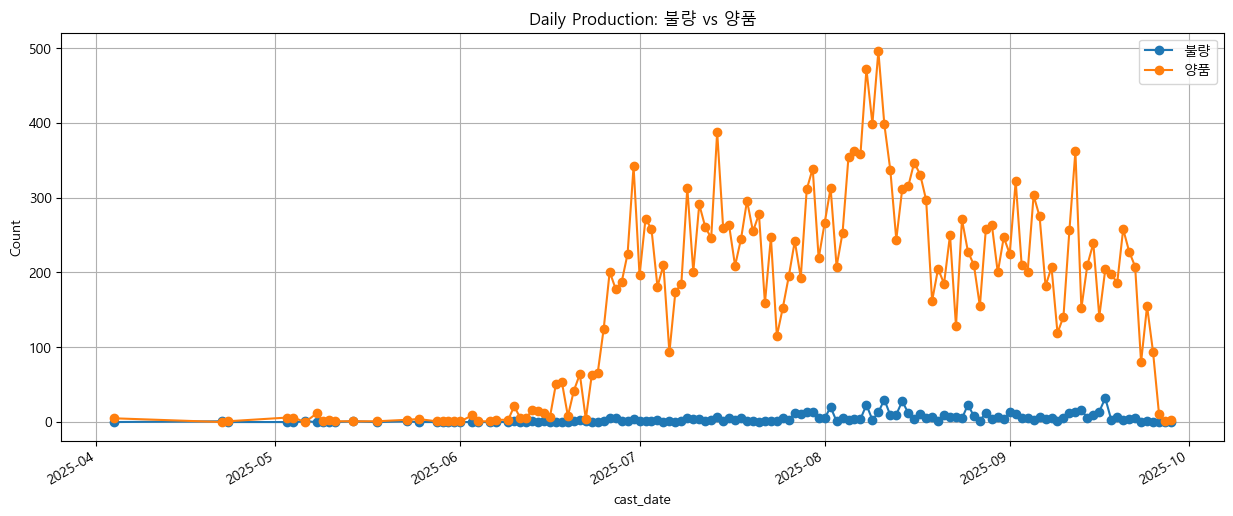

In [ ]:
# 1. 날짜별/양부판정별로 데이터 개수(count)를 피벗합니다.
# index: 날짜, columns: 양품(0)/불량(1), values: 슬라브번호(개수 세기용)
df_time_pivot = final_df.pivot_table(index='cast_date', 
                                     columns='judge', 
                                     values='slab_no', 
                                     aggfunc='count', 
                                     fill_value=0)

# 2. 컬럼 이름을 보기 좋게 바꿉니다.
df_time_pivot.columns = ['불량', '양품']

# 3. 시계열 그래프 그리기
df_time_pivot.plot(figsize=(15, 6), marker='o')
plt.title('Daily Production: 불량 vs 양품')
plt.ylabel('Count')
plt.grid(True)
plt.show()

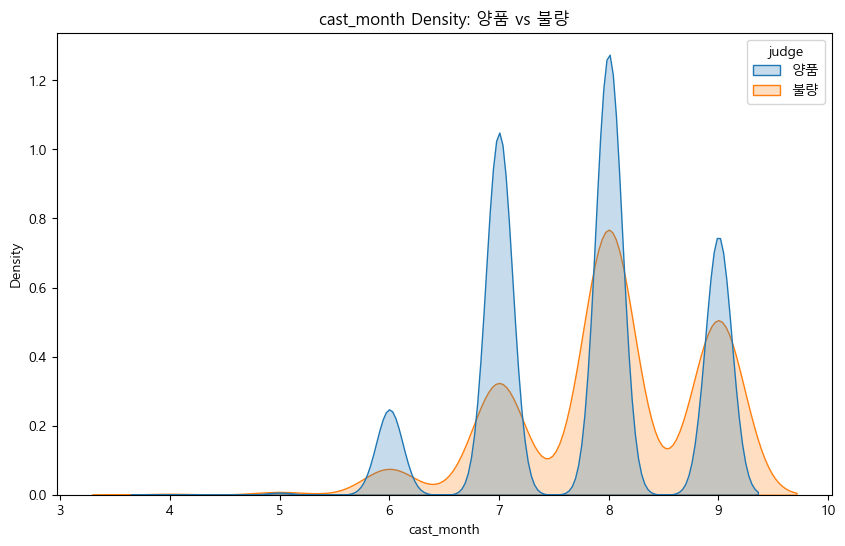

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=final_df, x='cast_month', hue='judge', fill=True, common_norm=False)
plt.title('cast_month Density: 양품 vs 불량')
plt.show()

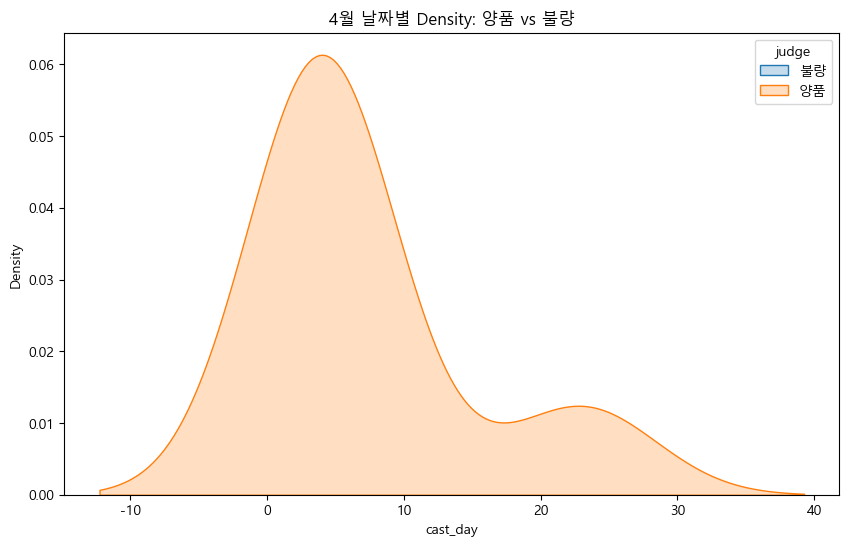

In [ ]:
plt.figure(figsize=(10, 6))
df_june = final_df[final_df['cast_month'] == 4]
sns.kdeplot(data=df_june, x='cast_day', hue='judge', fill=True, common_norm=False)
plt.title('4월 날짜별 Density: 양품 vs 불량')
plt.show()

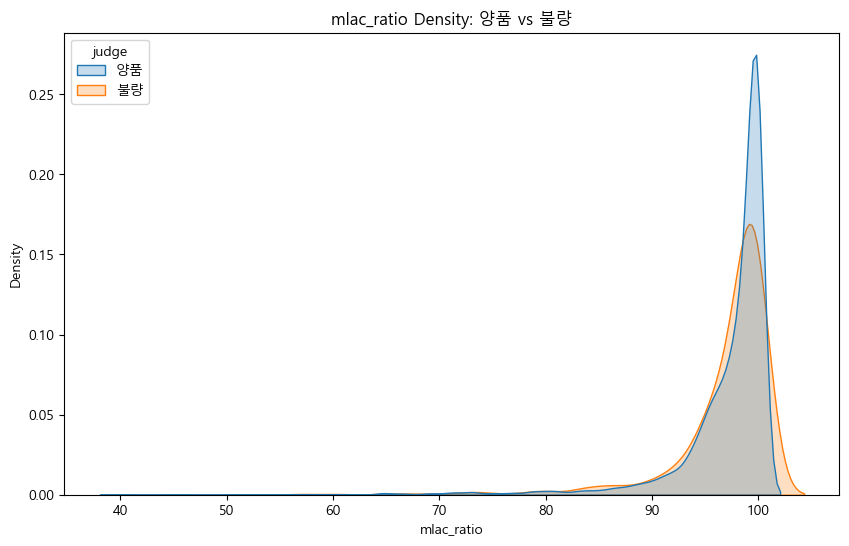

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=final_df, x='mlac_ratio', hue='judge', fill=True, common_norm=False)
plt.title('mlac_ratio Density: 양품 vs 불량')
plt.show()

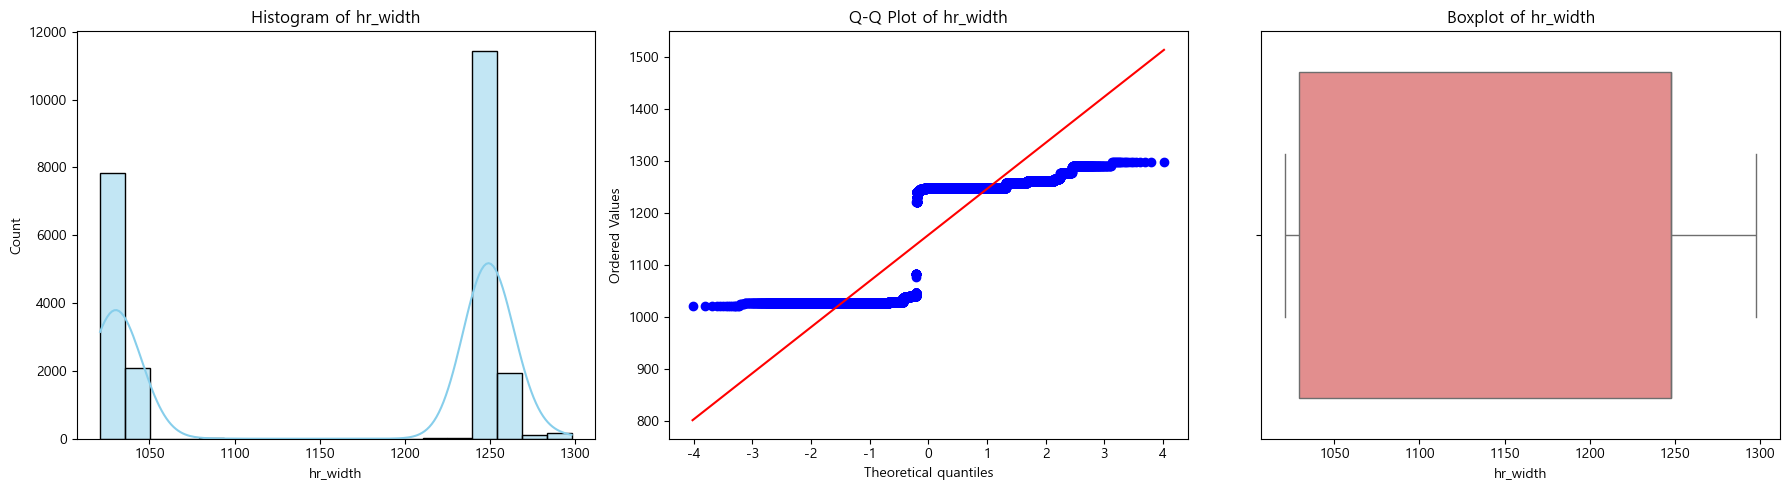

--------------------------------------------------
 [ hr_width 정규성 분석 결과 ]
--------------------------------------------------
- 왜도 (Skewness): -0.3172  (0에 가까울수록 정규성 높음)
- 첨도 (Kurtosis): -1.8843  (0에 가까울수록 정규성 높음)
- K-S Test: p-value = 0.0000
--------------------------------------------------
 * 해석 가이드:
   1) p-value < 0.05 : 정규성을 만족하지 않음 (비모수 검정 권장)
   2) 왜도 > 2.0 : 데이터가 심하게 치우쳐 있음
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_normality(final_df, column_name):
    # 1. 데이터 준비 (결측치 제거)
    data = final_df[column_name].dropna()
    
    # 그래프 설정
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 2. 시각화 - 히스토그램 & KDE
    sns.histplot(data, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {column_name}')
    
    # 3. 시각화 - Q-Q Plot (정규성 확인의 핵심)
    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {column_name}')
    
    # 4. 시각화 - Boxplot (이상치 확인)
    sns.boxplot(x=data, ax=axes[2], color='lightcoral')
    axes[2].set_title(f'Boxplot of {column_name}')
    
    plt.tight_layout()
    plt.show()
    
    # 5. 통계적 검정
    print("-" * 50)
    print(f" [ {column_name} 정규성 분석 결과 ]")
    print("-" * 50)
    
    # 왜도(Skewness) & 첨도(Kurtosis)
    print(f"- 왜도 (Skewness): {data.skew():.4f}  (0에 가까울수록 정규성 높음)")
    print(f"- 첨도 (Kurtosis): {data.kurt():.4f}  (0에 가까울수록 정규성 높음)")
    
    # Shapiro-Wilk 검정 (샘플 5000개 이하 권장)
    if len(data) <= 5000:
        shapiro_test = stats.shapiro(data)
        print(f"- Shapiro-Wilk Test: p-value = {shapiro_test.pvalue:.4f}")
    else:
        # 샘플이 많을 경우 Kolmogorov-Smirnov 검정
        ks_test = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
        print(f"- K-S Test: p-value = {ks_test.pvalue:.4f}")
    
    print("-" * 50)
    print(" * 해석 가이드:")
    print("   1) p-value < 0.05 : 정규성을 만족하지 않음 (비모수 검정 권장)")
    print("   2) 왜도 > 2.0 : 데이터가 심하게 치우쳐 있음")
    print("-" * 50)

# 사용 예시 (df가 이미 있다고 가정)
analyze_normality(final_df, 'hr_width')

In [ ]:
from scipy import stats

# 1. 그룹 분리 (Y가 target, X가 mlac_ratio라고 가정)
good_group = final_df[final_df['judge'] == '양품']['hr_width']
bad_group = final_df[final_df['judge'] == '불량']['hr_width']

# 2. Mann-Whitney U-test 실시
u_stat, p_value = stats.mannwhitneyu(good_group, bad_group, alternative='two-sided')

print(f"Mann-Whitney U 통계량: {u_stat:.2f}")
print(f"p-value: {p_value:.4f}")

# 3. 결과 해석
if p_value < 0.05:
    print("결과: 양품과 불량 그룹 간 mlac_ratio는 통계적으로 유의미한 차이가 있습니다. (Vital Few 후보!)")
else:
    print("결과: 두 그룹 간 유의미한 차이가 발견되지 않았습니다.")

Mann-Whitney U 통계량: 7589643.50
p-value: 0.0312
결과: 양품과 불량 그룹 간 mlac_ratio는 통계적으로 유의미한 차이가 있습니다. (Vital Few 후보!)


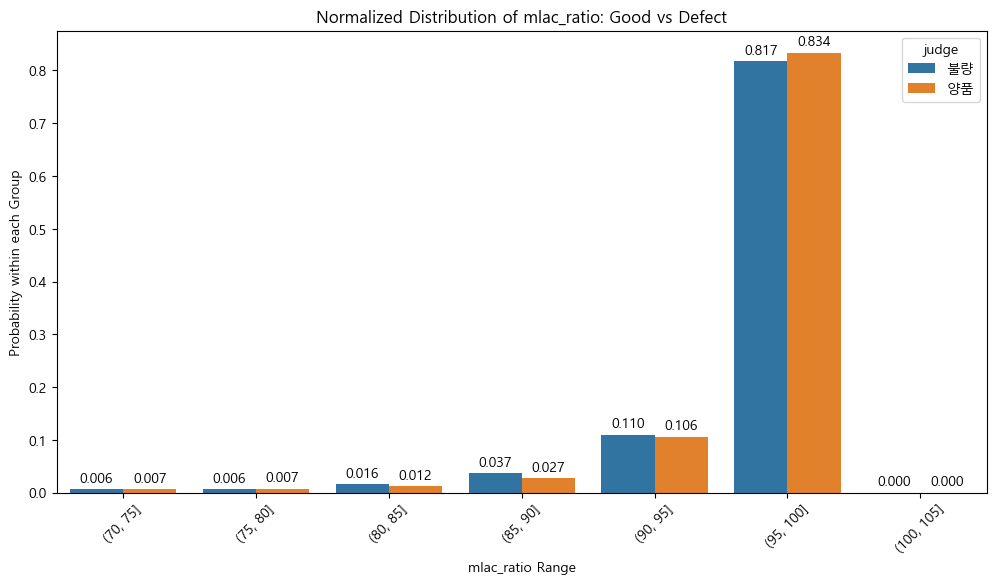

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. mlac_ratio 구간(Bin) 설정 
# 데이터의 최소/최대값을 확인하여 적절한 범위를 정합니다. (예: 70부터 105까지 5 단위)
bins = np.arange(70, 110, 5) 
final_df['mlac_bin'] = pd.cut(final_df['mlac_ratio'], bins=bins)

# 2. 그룹별 비율(Probability) 직접 계산 (오류 방지를 위한 사전 계산 방식)
# 구간별/판정별 데이터 개수 합계
df_counts = final_df.groupby(['mlac_bin', 'judge']).size().reset_index(name='count')

# 각 judge(양품/불량)의 전체 합계 계산
total_by_judge = final_df['judge'].value_counts()

# '비율(ratio)' 컬럼 생성: 각 개수를 해당 judge 그룹의 전체 합계로 나눔
df_counts['ratio'] = df_counts.apply(
    lambda x: x['count'] / total_by_judge[x['judge']] if total_by_judge[x['judge']] > 0 else 0, axis=1
)

# 3. 그래프 시각화
plt.figure(figsize=(12, 6))

# 범례 이름 매핑 (필요 시 실행)
# final_df['judge_label'] = final_df['judge'].map({0: '양품', 1: '불량'})

# x축은 mlac_ratio 구간, y축은 해당 그룹 내 비중(Ratio)
ax = sns.barplot(data=df_counts, x='mlac_bin', y='ratio', hue='judge')

# 4. 막대 위에 비율 수치 표시
if ax.containers:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

# 5. 그래프 세부 설정
plt.title('Normalized Distribution of mlac_ratio: Good vs Defect')
plt.ylabel('Probability within each Group')
plt.xlabel('mlac_ratio Range')
plt.xticks(rotation=45)

plt.show()

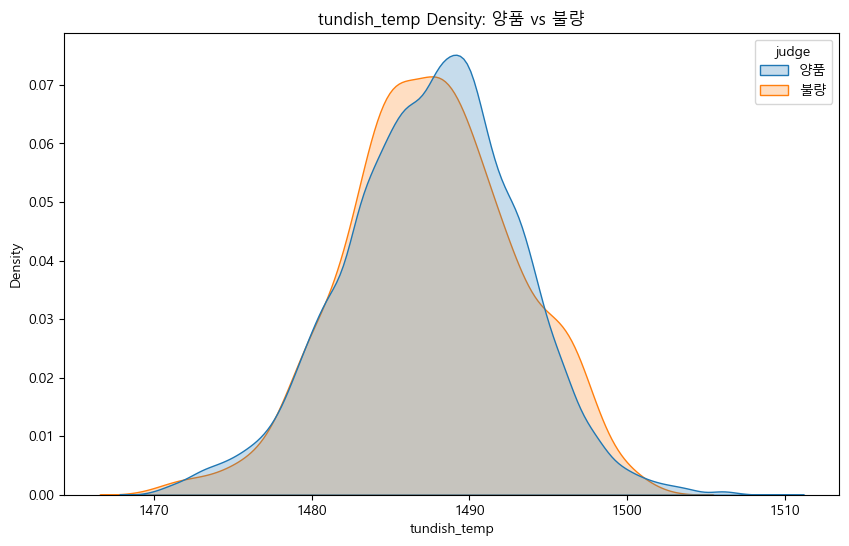

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=final_df, x='tundish_temp', hue='judge', fill=True, common_norm=False)
plt.title('tundish_temp Density: 양품 vs 불량')
plt.show()


# 거의 똑같은 형태(교수님 피셜) -> p-value 진행시, 유의미한 변수로 해석 x

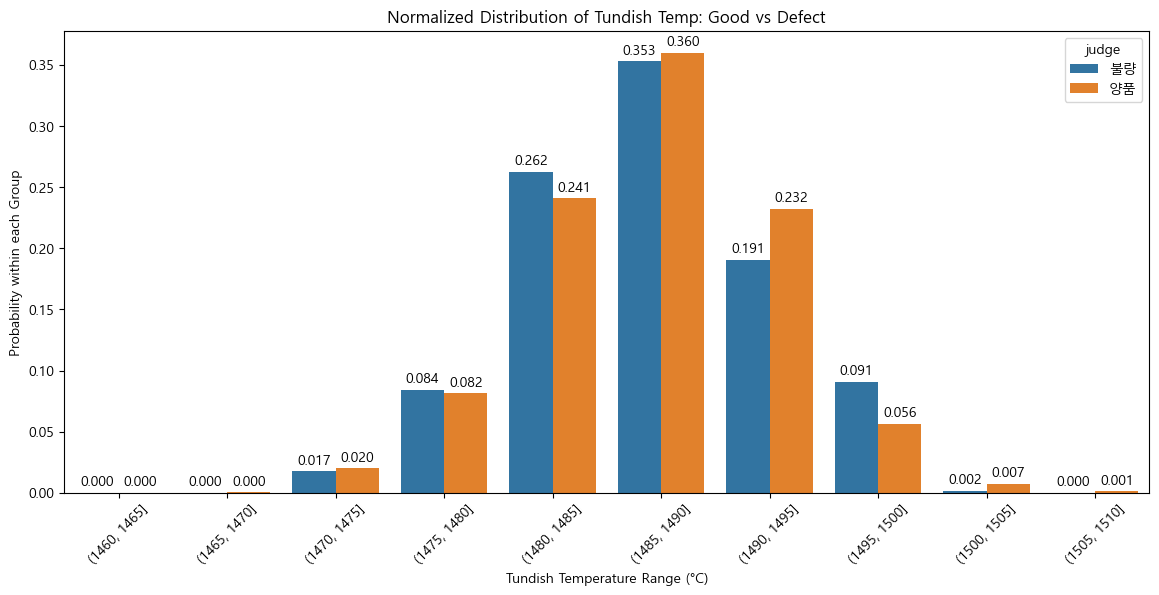

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 온도 구간(Bin) 설정 (데이터 분포에 맞춰 1460도부터 1510도까지 5도 간격)
bins = np.arange(1460, 1515, 5)
final_df['temp_bin'] = pd.cut(final_df['tundish_temp'], bins=bins)

# 2. 그룹별 비율(Probability) 직접 계산
# 구간별/판정별 데이터 개수 합계
df_counts = final_df.groupby(['temp_bin', 'judge']).size().reset_index(name='count')

# 각 judge(양품/불량)의 전체 합계 계산 (0: 양품, 1: 불량 가정)
total_by_judge = final_df['judge'].value_counts()

# '비율(ratio)' 컬럼 생성: 각 개수를 해당 그룹의 전체 합계로 나눔
df_counts['ratio'] = df_counts.apply(
    lambda x: x['count'] / total_by_judge[x['judge']] if total_by_judge[x['judge']] > 0 else 0, axis=1
)

# 3. 그래프 시각화
plt.figure(figsize=(14, 6))

# 범례 이름 매핑 (필요시 실행)
# final_df['judge_label'] = final_df['judge'].map({0: '양품', 1: '불량'})

# x축은 온도 구간, y축은 해당 그룹 내 비중(Ratio)
ax = sns.barplot(data=df_counts, x='temp_bin', y='ratio', hue='judge')

# 4. 막대 위에 비율 수치 표시 (가독성 향상)
if ax.containers:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

# 5. 그래프 세부 설정
plt.title('Normalized Distribution of Tundish Temp: Good vs Defect')
plt.ylabel('Probability within each Group')
plt.xlabel('Tundish Temperature Range (°C)')
plt.xticks(rotation=45)

plt.show()

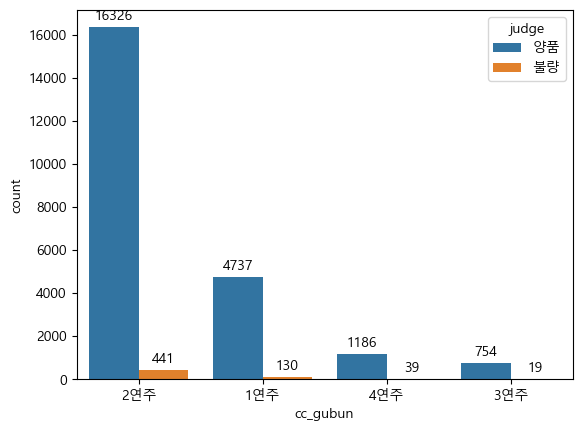

In [ ]:
graph = sns.countplot(x="cc_gubun", hue="judge", data=final_df)

for container in graph.containers:
    graph.bar_label(container, padding=3)

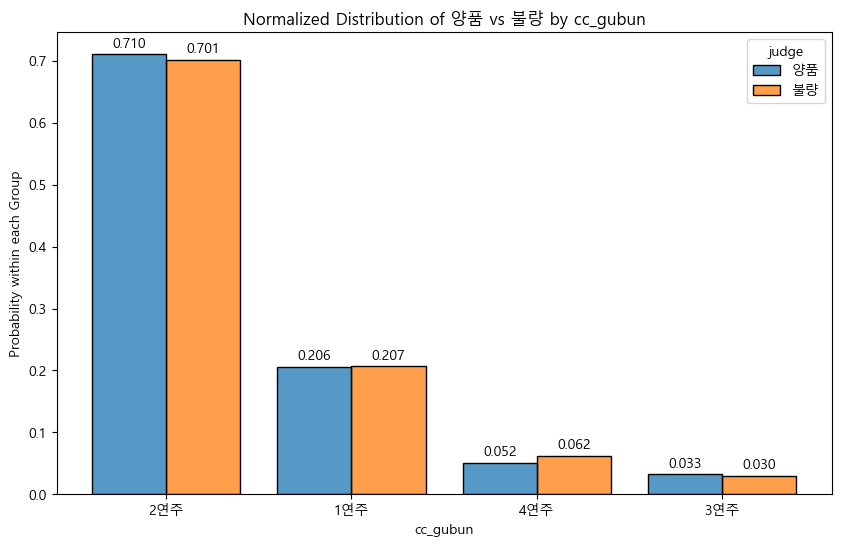

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. stat='probability' : 개수가 아닌 비율(0~1)로 계산
# 2. common_norm=False : 양품과 불량 각각의 합계를 1로 정규화 -> 생산 비중에 비해 불량이 많이 나오는가
# 3. multiple='dodge' : 막대를 옆으로 나란히 배치
graph = sns.histplot(data=final_df, x="cc_gubun", hue="judge", 
                     stat="probability", common_norm=False, 
                     multiple="dodge", shrink=.8, discrete=True)

# 막대 위에 비율(%) 표시
for container in graph.containers:
    graph.bar_label(container, fmt='%.3f', padding=3)

plt.ylabel("Probability within each Group")
plt.title("Normalized Distribution of 양품 vs 불량 by cc_gubun")
plt.show()

# 4연주는 생산 비중 대비 불량이 발생할 확률이 약 19% 정도 더 높다($\frac{0.062-0.052}{0.052} \approx 0.192$)

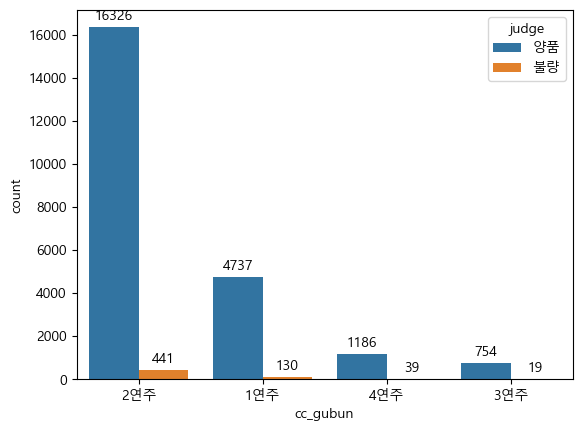

In [ ]:
graph =sns.countplot(x="cc_gubun", hue="judge", data=final_df)

for container in graph.containers:
    graph.bar_label(container, padding=3)

발견된 3개 봉우리의 중심값: [np.float64(3.078782163302197), np.float64(3.8499718065495547), np.float64(5.117032151690031)]
추천 분할 경계값: 3.46, 4.48


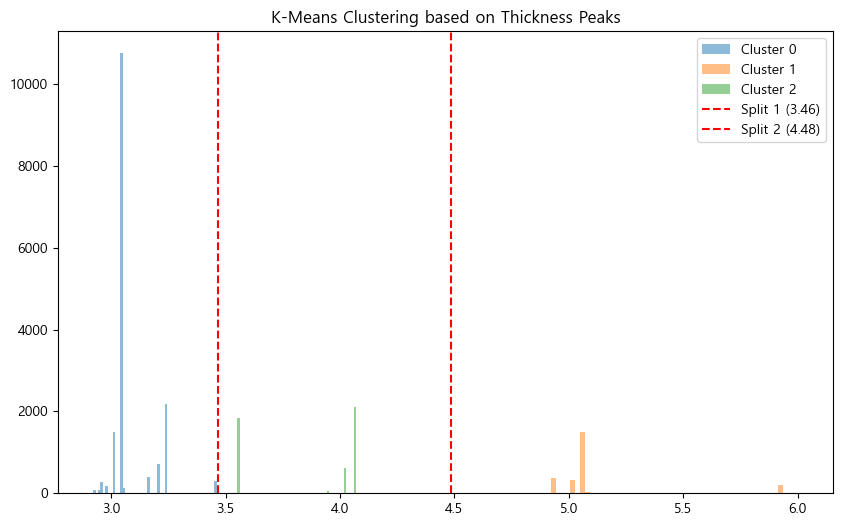

In [ ]:
# 열연 두께 구간화

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 데이터 준비 (1차원 데이터를 2차원으로 변환)
X_thick = final_df[['hr_thick']]

# 2. K-Means 모델 설정 (군집 수 3개)
# 데이터의 밀집도가 높은 '봉우리' 3개를 스스로 찾습니다.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
final_df['cluster'] = kmeans.fit_predict(X_thick)

# 3. 군집별 중심값(봉우리 위치) 확인 및 경계값 계산
centers = sorted(kmeans.cluster_centers_.flatten())
print(f"발견된 3개 봉우리의 중심값: {centers}")

# 중심값 사이의 중간 지점을 경계값으로 설정
threshold1 = (centers[0] + centers[1]) / 2
threshold2 = (centers[1] + centers[2]) / 2

print(f"추천 분할 경계값: {threshold1:.2f}, {threshold2:.2f}")

# 4. 시각화로 확인
plt.figure(figsize=(10, 6))
for i in range(3):
    subset = final_df[final_df['cluster'] == i]
    plt.hist(subset['hr_thick'], bins=50, alpha=0.5, label=f'Cluster {i}')

plt.axvline(threshold1, color='red', linestyle='--', label=f'Split 1 ({threshold1:.2f})')
plt.axvline(threshold2, color='red', linestyle='--', label=f'Split 2 ({threshold2:.2f})')
plt.title('K-Means Clustering based on Thickness Peaks')
plt.legend()
plt.show()

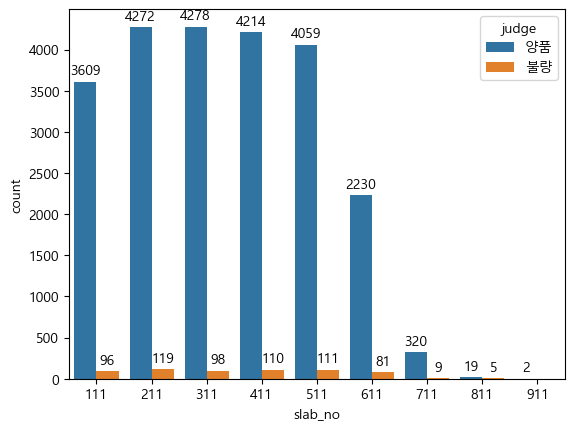

In [ ]:
graph =sns.countplot(x="slab_no", hue="judge", data=final_df)

for container in graph.containers:
    graph.bar_label(container, padding=3)

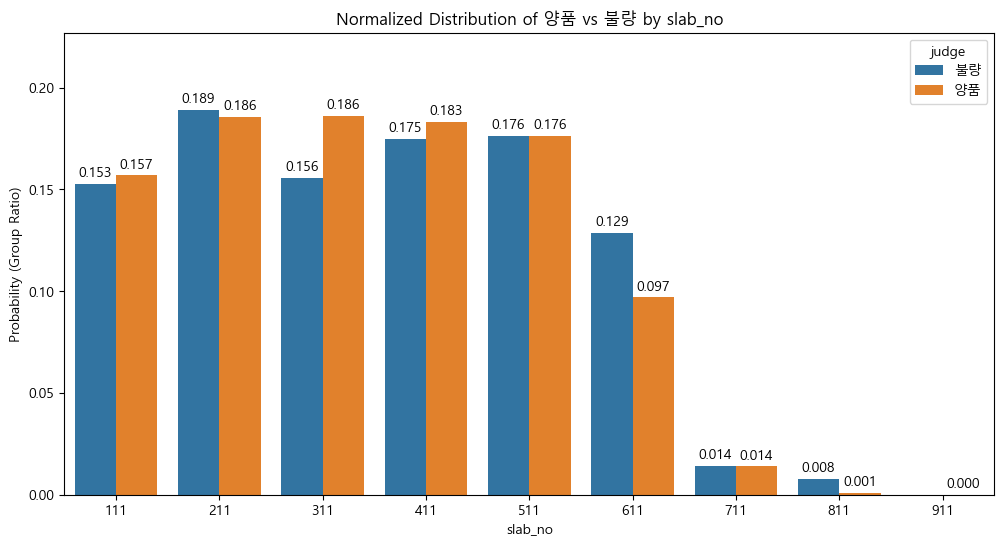

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 그룹별 비율 직접 계산하기
# slab_no와 judge별로 개수를 세고, 각 judge 그룹의 합계로 나눕니다.
df_counts = final_df.groupby(['slab_no', 'judge']).size().reset_index(name='count')

# 각 판정(양품/불량)의 전체 합계 구하기
total_counts = final_df['judge'].value_counts()

# 비율(Probability) 컬럼 생성: 각 개수를 해당 그룹의 전체 합계로 나눔
df_counts['probability'] = df_counts.apply(
    lambda x: x['count'] / total_counts[x['judge']], axis=1
)

# 2. 그래프 그리기 (barplot은 containers 오류가 거의 없습니다)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_counts, x='slab_no', y='probability', hue='judge')

# 3. 막대 위에 수치 표시 (안전하게 체크 추가)
if ax.containers:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

# 4. 마무리 세팅
plt.title('Normalized Distribution of 양품 vs 불량 by slab_no')
plt.ylabel('Probability (Group Ratio)')
plt.ylim(0, df_counts['probability'].max() * 1.2) # 수치가 잘 안 잘리게 여유 공간 확보
plt.show()

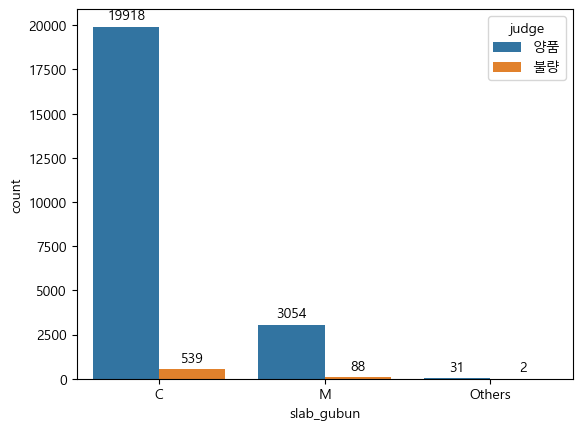

In [ ]:
graph = sns.countplot(x="slab_gubun", hue="judge", data=final_df)

for container in graph.containers:
    graph.bar_label(container, padding=3)

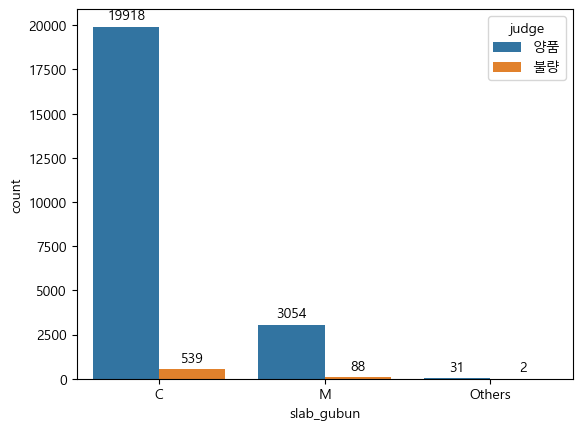

In [ ]:
graph = sns.countplot(x="slab_gubun", hue="judge", data=final_df)

for container in graph.containers:
    graph.bar_label(container, padding=3)

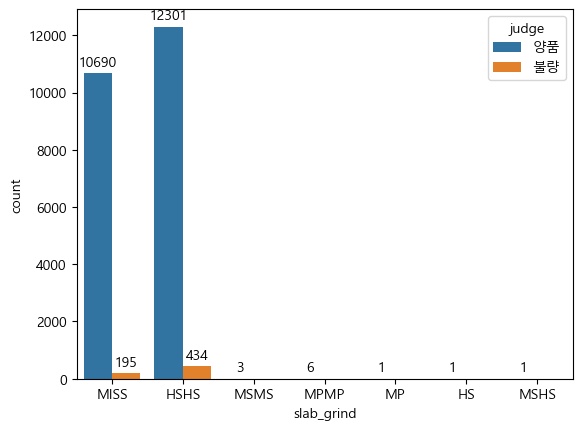

In [ ]:
graph = sns.countplot(x="slab_grind", hue="judge", data=final_df)

for container in graph.containers:
    graph.bar_label(container, padding=3)

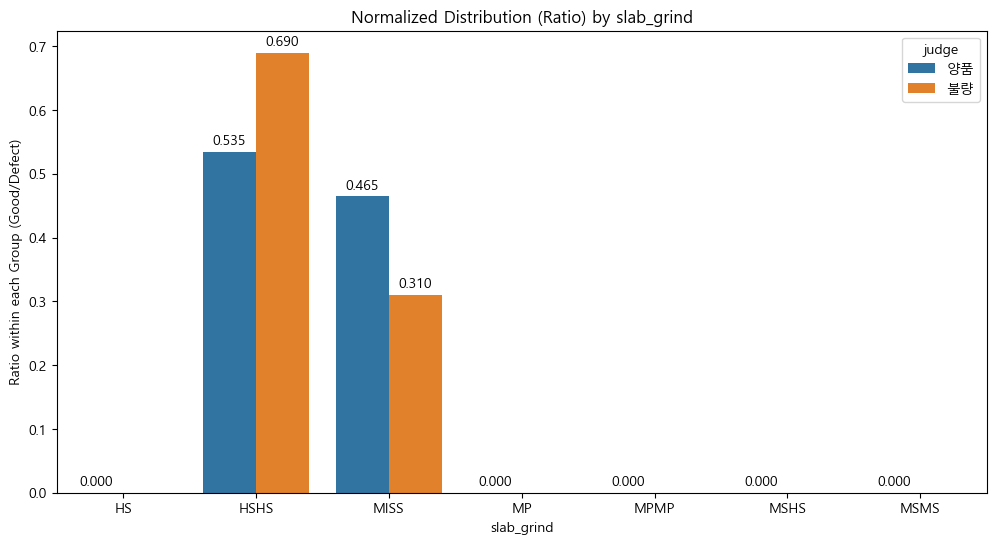

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 사전 계산: slab_grind와 judge별로 개수를 세고 비율을 구합니다.
# slab_grind별, judge별 데이터 개수 합계
df_counts = final_df.groupby(['slab_grind', 'judge']).size().reset_index(name='count')

# 각 judge(양품/불량)의 전체 합계 계산
total_by_judge = final_df['judge'].value_counts()

# '비율(ratio)' 컬럼 생성: 각 개수를 해당 judge의 전체 합계로 나눔
# 예: (HSHS 불량 개수 / 전체 불량 개수 합계)
df_counts['ratio'] = df_counts.apply(
    lambda x: x['count'] / total_by_judge[x['judge']], axis=1
)

# 2. 그래프 시각화
plt.figure(figsize=(12, 6))

# 개수가 아닌 계산된 'ratio'를 y축으로 사용합니다.
ax = sns.barplot(data=df_counts, x='slab_grind', y='ratio', hue='judge')

# 3. 막대 위에 비율 수치 표시 (안전성 체크 포함)
if ax.containers:
    for container in ax.containers:
        # 소수점 3자리까지 표시
        ax.bar_label(container, fmt='%.3f', padding=3)

# 4. 그래프 세부 설정
plt.title('Normalized Distribution (Ratio) by slab_grind')
plt.ylabel('Ratio within each Group (Good/Defect)')
plt.xlabel('slab_grind')

plt.show()

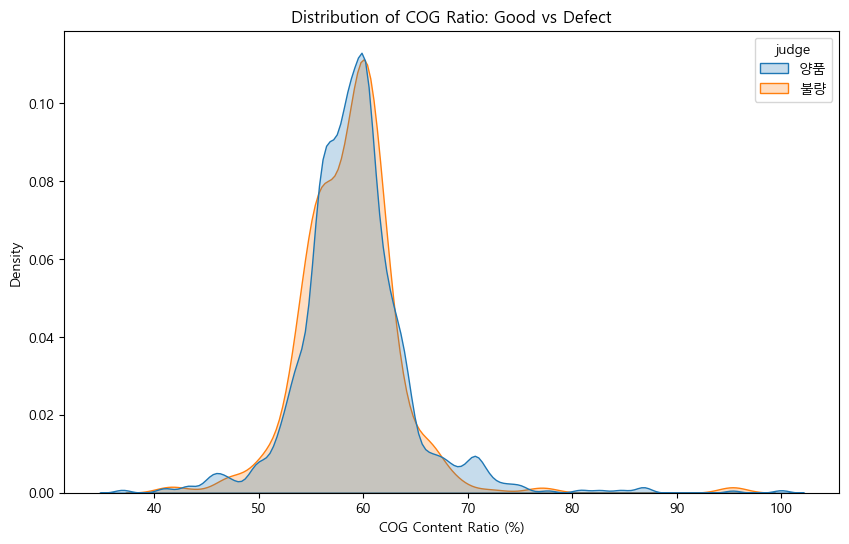

In [ ]:
plt.figure(figsize=(10, 6))
# common_norm=False를 써야 개수 차이에 상관없이 모양 비교가 가능합니다.
sns.kdeplot(data=final_df, x='f_cog_per', hue='judge', fill=True, common_norm=False)

plt.title('Distribution of COG Ratio: Good vs Defect')
plt.xlabel('COG Content Ratio (%)')
plt.show()

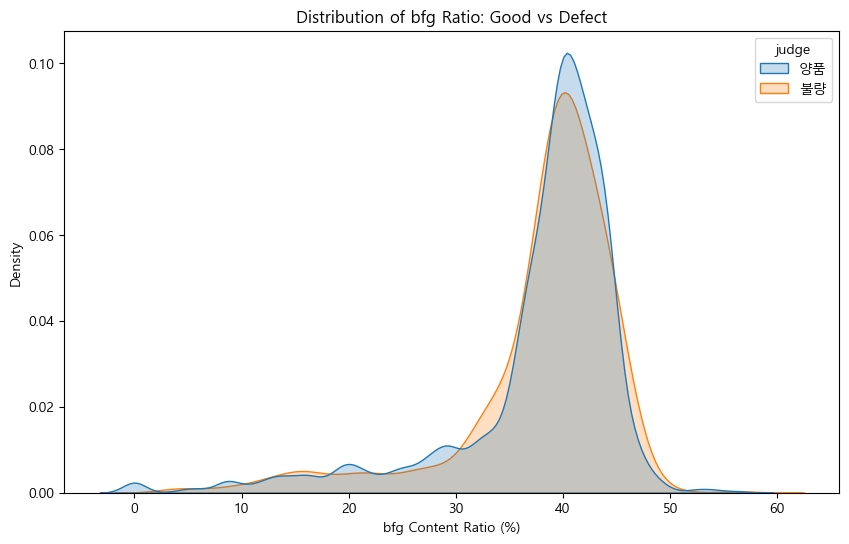

In [ ]:
plt.figure(figsize=(10, 6))
# common_norm=False를 써야 개수 차이에 상관없이 모양 비교가 가능합니다.
sns.kdeplot(data=final_df, x='f_bfg_per', hue='judge', fill=True, common_norm=False)

plt.title('Distribution of bfg Ratio: Good vs Defect')
plt.xlabel('bfg Content Ratio (%)')
plt.show()

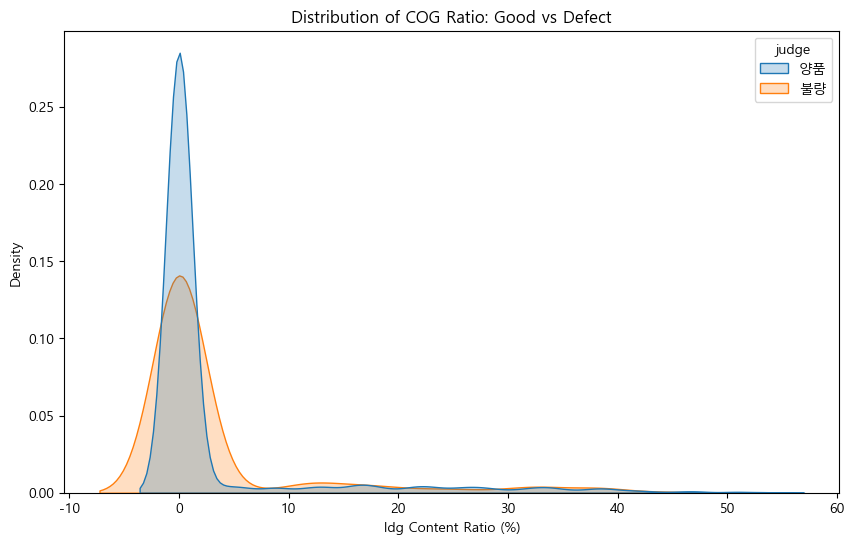

In [ ]:
plt.figure(figsize=(10, 6))
# common_norm=False를 써야 개수 차이에 상관없이 모양 비교가 가능합니다.
sns.kdeplot(data=final_df, x='f_ldg_per', hue='judge', fill=True, common_norm=False)

plt.title('Distribution of COG Ratio: Good vs Defect')
plt.xlabel('ldg Content Ratio (%)')
plt.show()

In [ ]:
#hr_thick_group

<Axes: xlabel='hr_thick_group', ylabel='count'>

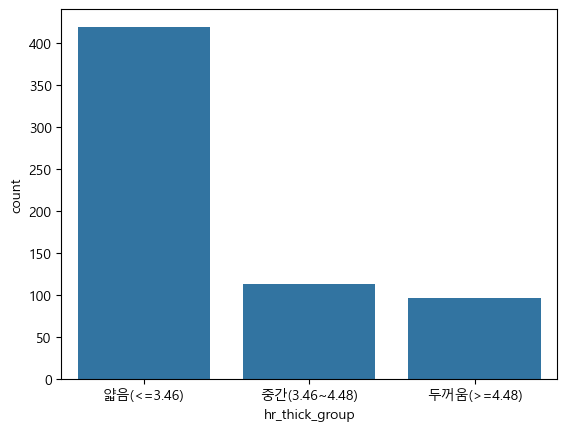

In [ ]:
sns.countplot(x="hr_thick_group", data=final_df[final_df['judge'] == '불량'])


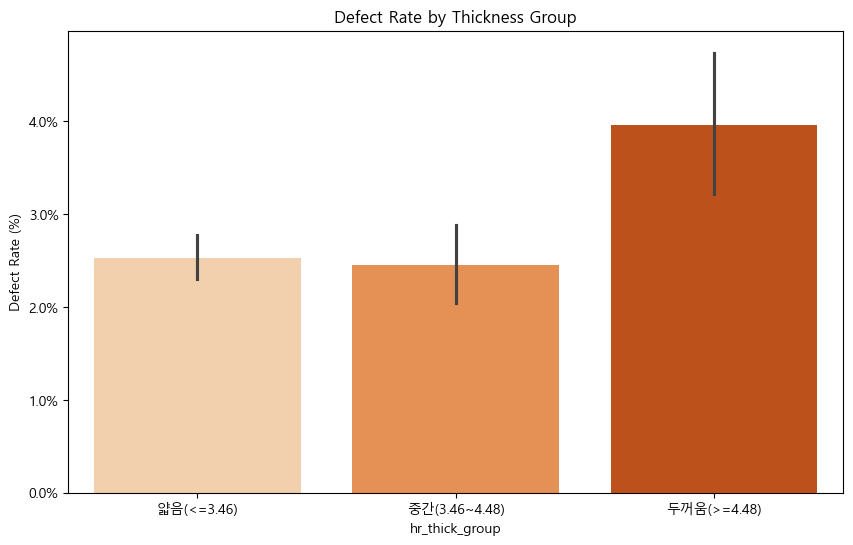

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 불량 여부를 0과 1로 변환 (불량이면 1, 양품이면 0)
final_df['is_defect'] = (final_df['judge'] == '불량').astype(int)

# 2. barplot 그리기 (y축이 'is_defect'의 평균, 즉 불량률이 됨)
plt.figure(figsize=(10, 6))
group_order = ['얇음(<=3.46)', '중간(3.46~4.48)', '두꺼움(>=4.48)'] # 순서 고정

sns.barplot(x="hr_thick_group", y="is_defect", data=final_df, 
            order=group_order, palette="Oranges")

# Y축을 백분율(%)로 표시하고 싶을 때
plt.gca().set_yticklabels(['{:,.1%}'.format(x) for x in plt.gca().get_yticks()])
plt.ylabel("Defect Rate (%)")
plt.title("Defect Rate by Thickness Group")
plt.show()

<Axes: xlabel='hr_thick_group', ylabel='count'>

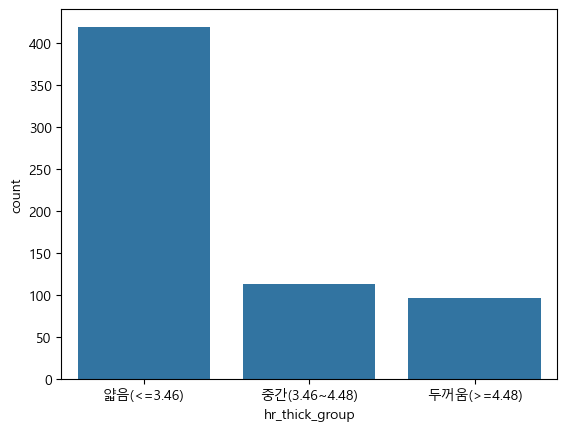

In [ ]:
sns.countplot(x="hr_thick_group", data=final_df[final_df['judge'] == '불량'])

<Axes: xlabel='hr_thick_group', ylabel='hr_width'>

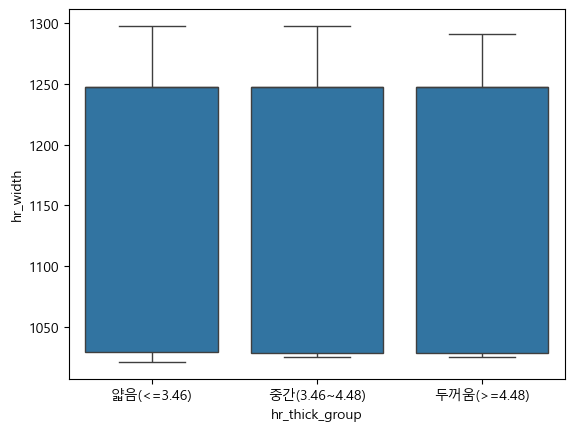

In [ ]:
sns.boxplot(y='hr_width', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='slab_width'>

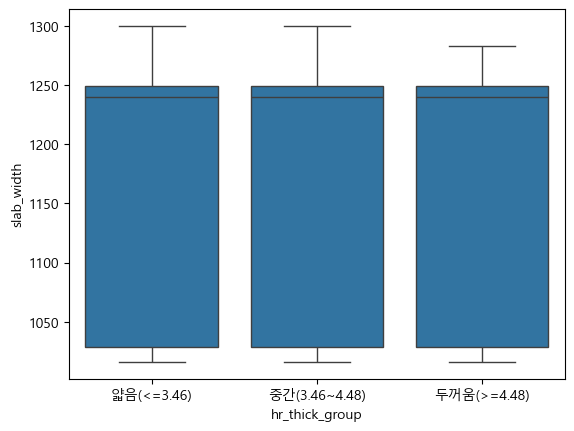

In [ ]:
sns.boxplot(y='slab_width', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='mlac_ratio'>

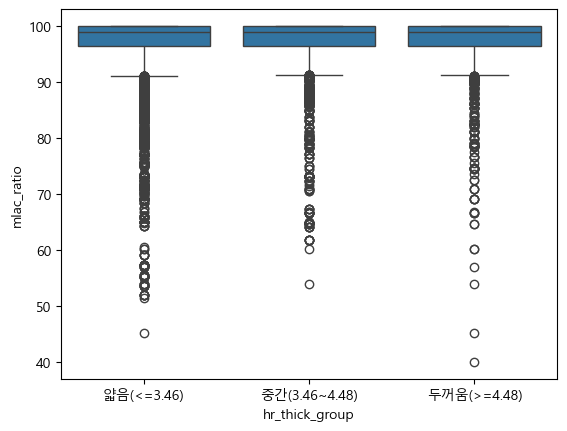

In [ ]:
sns.boxplot(y='mlac_ratio', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='f_ldg_per'>

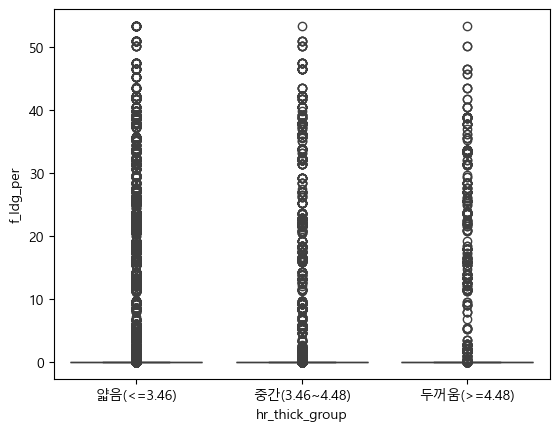

In [ ]:
sns.boxplot(y='f_ldg_per', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='f_ldg'>

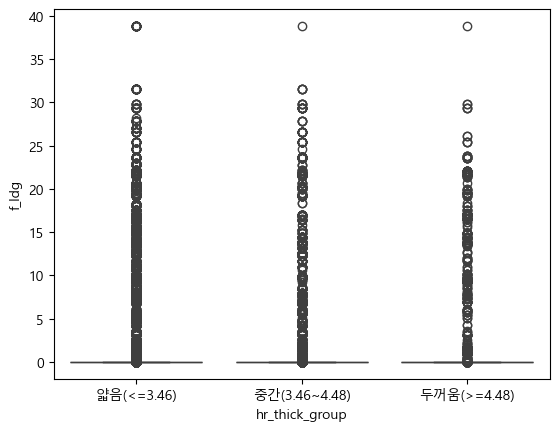

In [ ]:
sns.boxplot(y='f_ldg', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='f_sock_temp'>

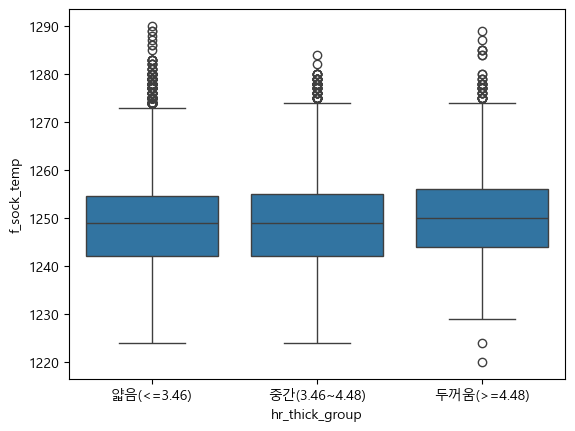

In [ ]:
sns.boxplot(y='f_sock_temp', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='ap_thick'>

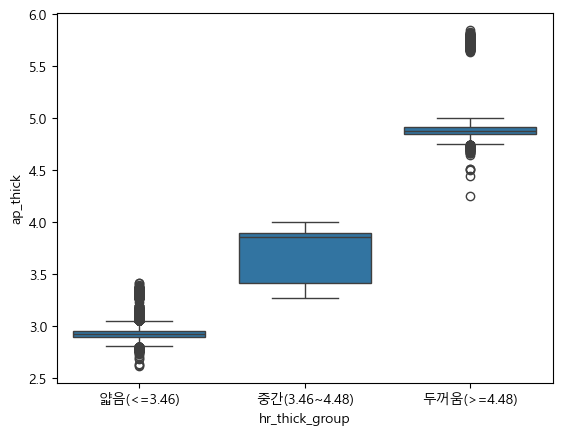

In [ ]:
sns.boxplot(y='ap_thick', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='ap_line_speed'>

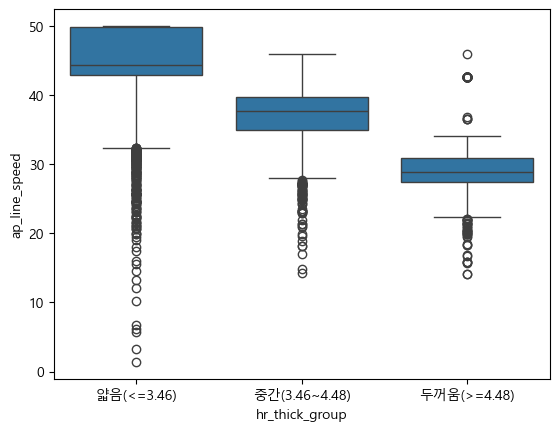

In [ ]:
sns.boxplot(y='ap_line_speed', x= 'hr_thick_group', data=final_df)

<Axes: xlabel='hr_thick_group', ylabel='f_total_time'>

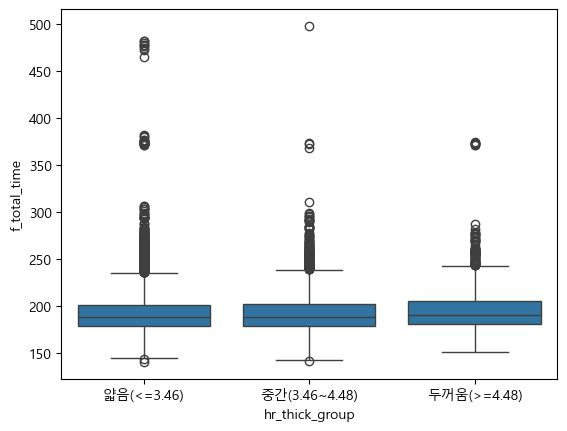

In [ ]:
sns.boxplot(y='f_total_time', x= 'hr_thick_group', data=final_df)

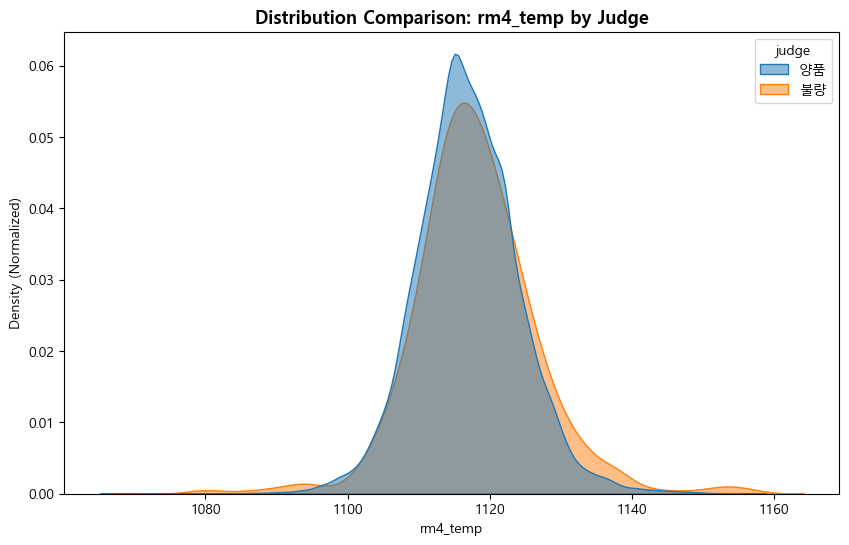

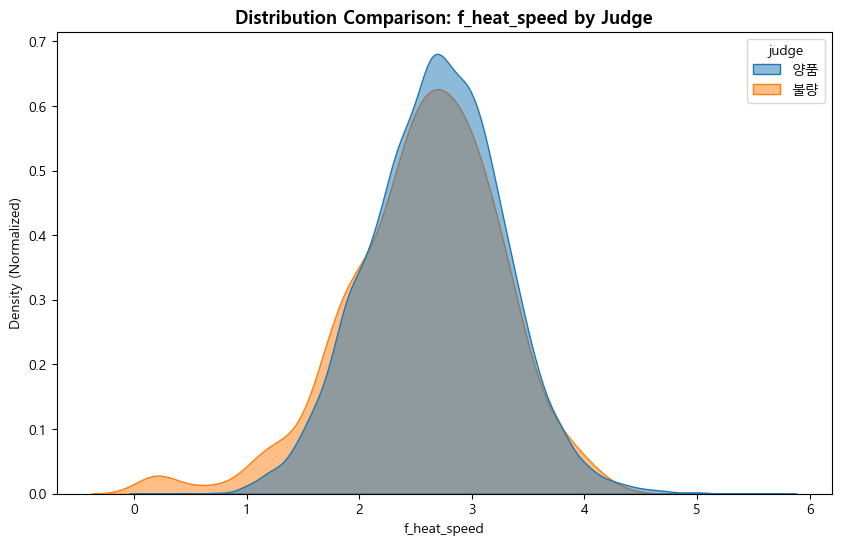

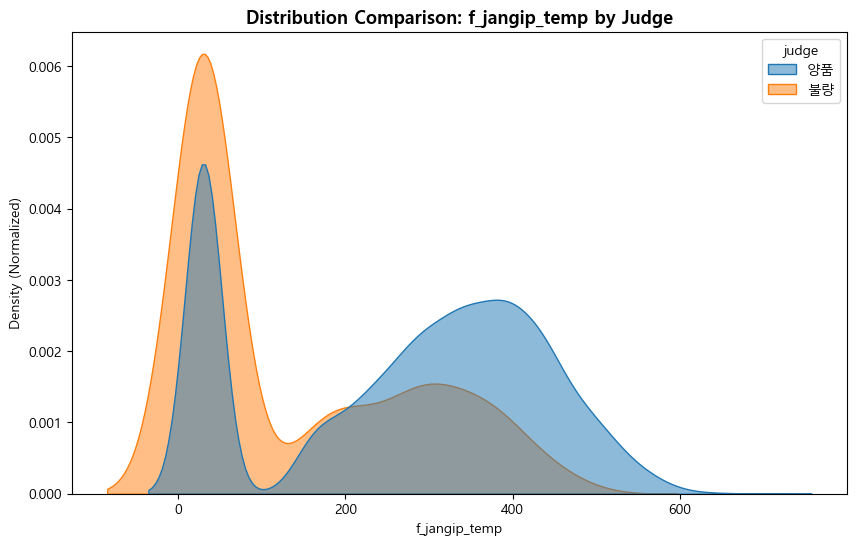

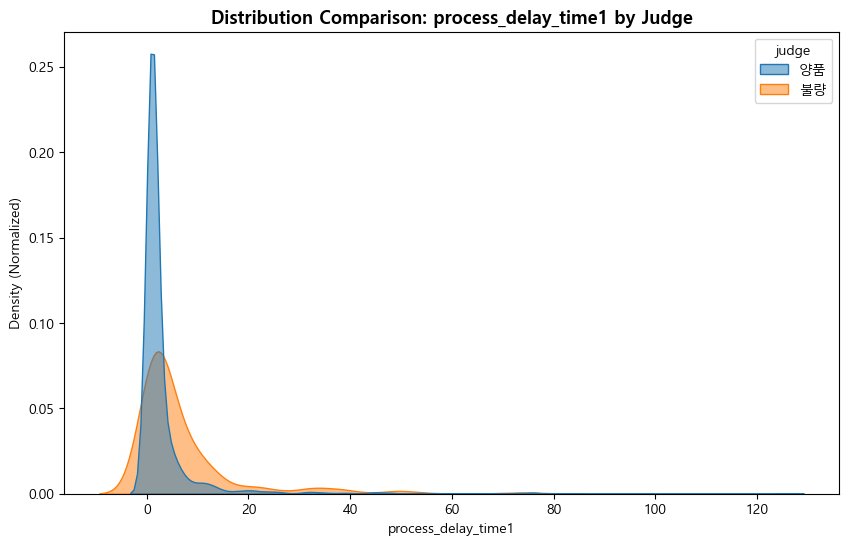

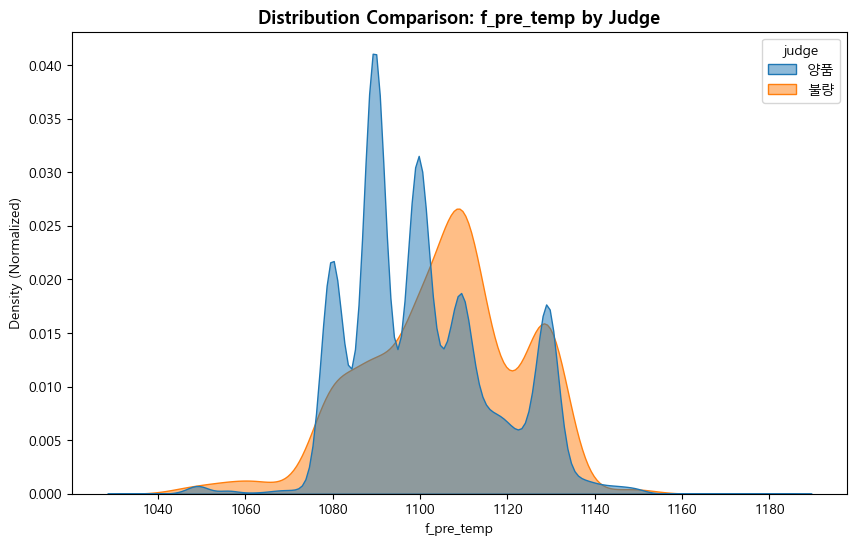

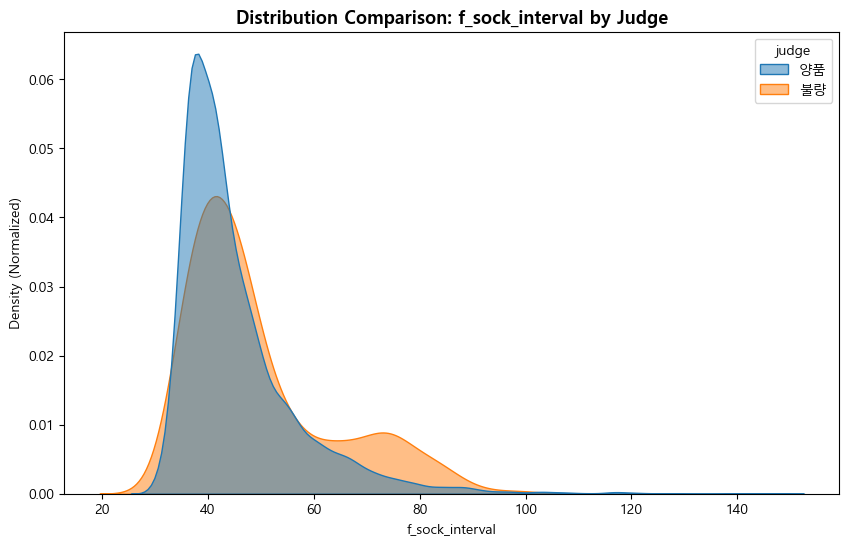

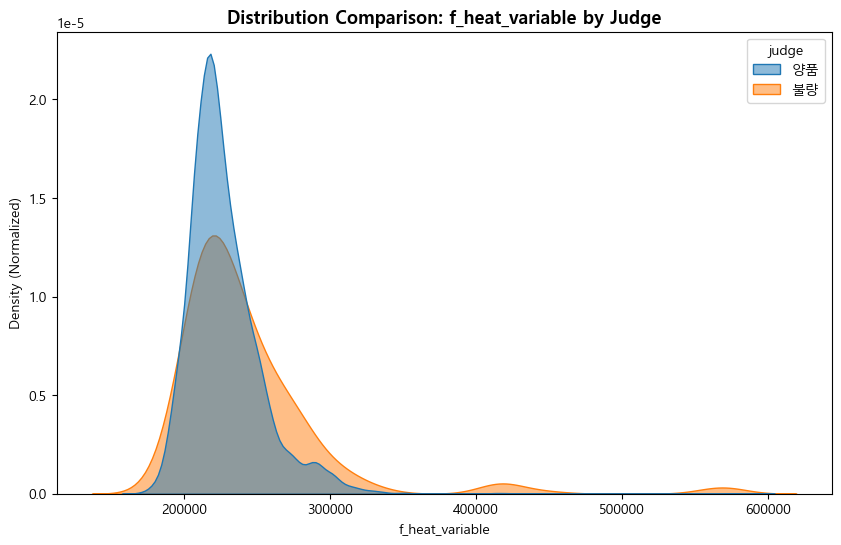

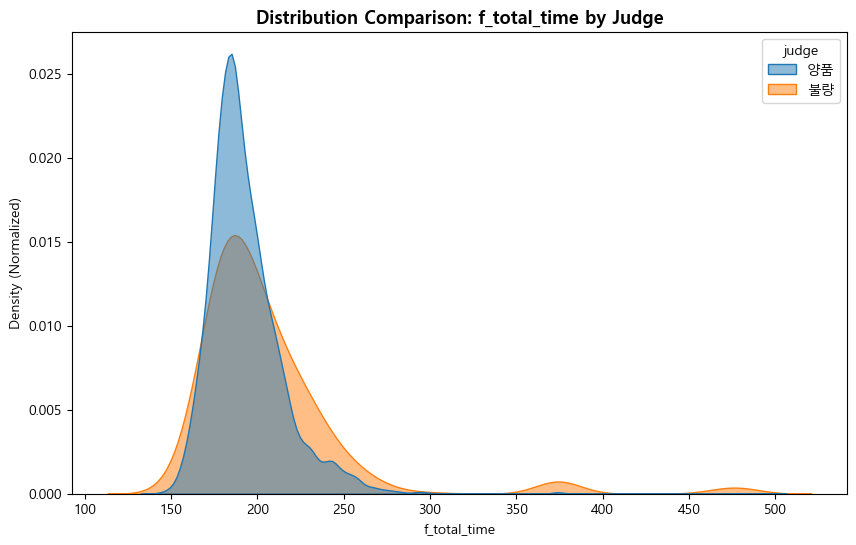

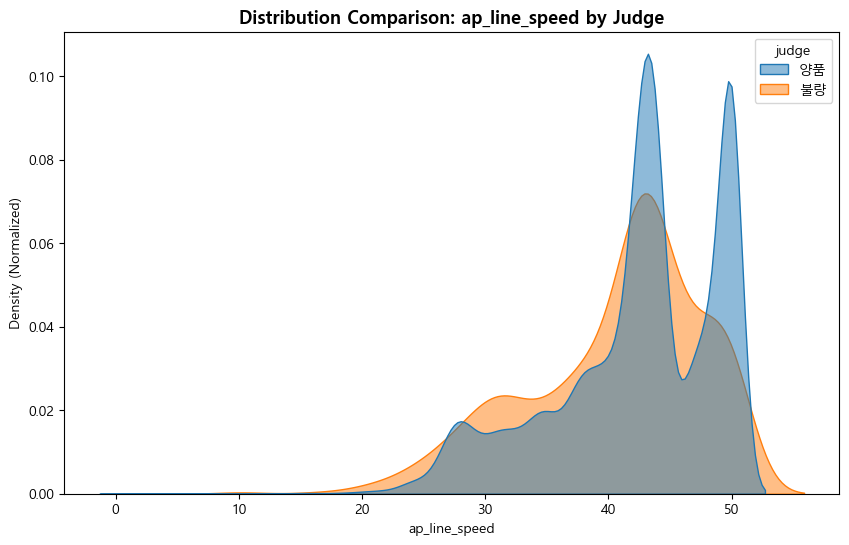

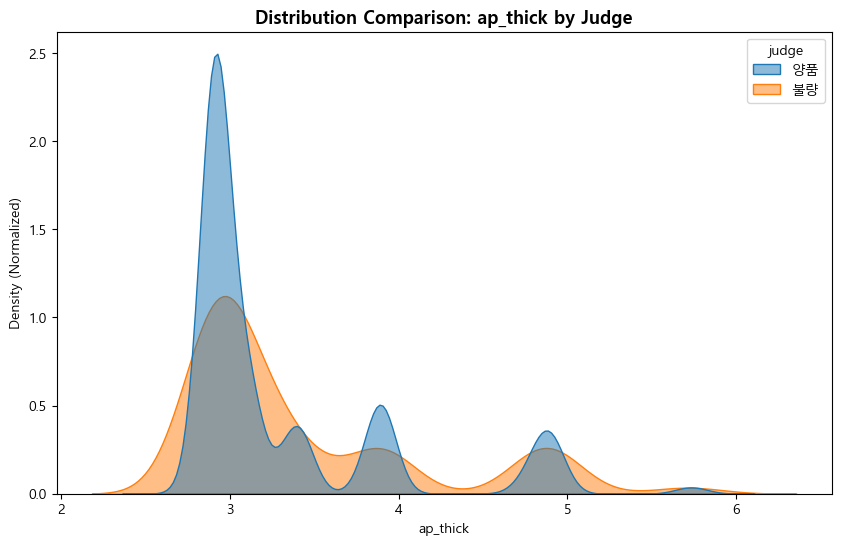

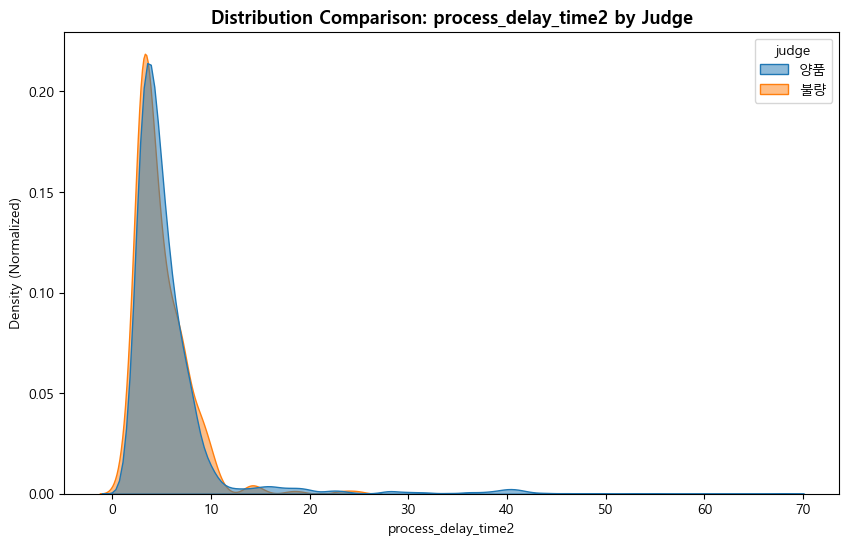

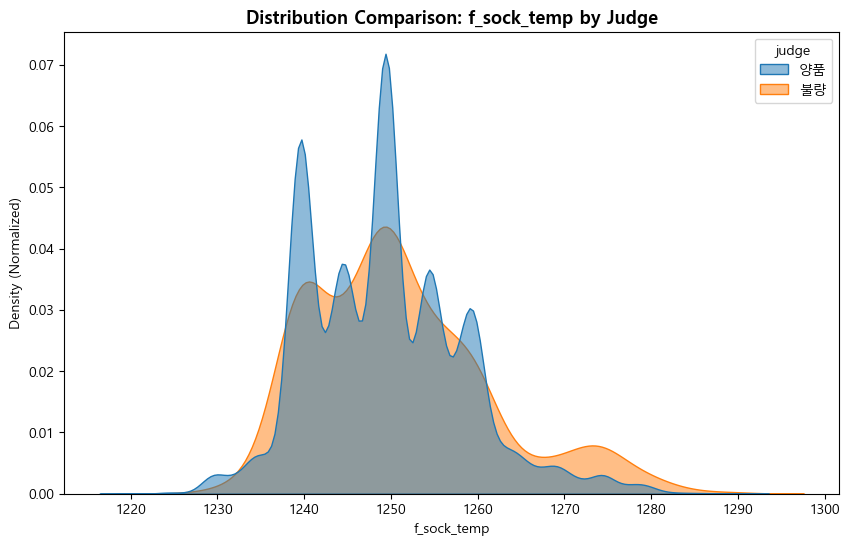

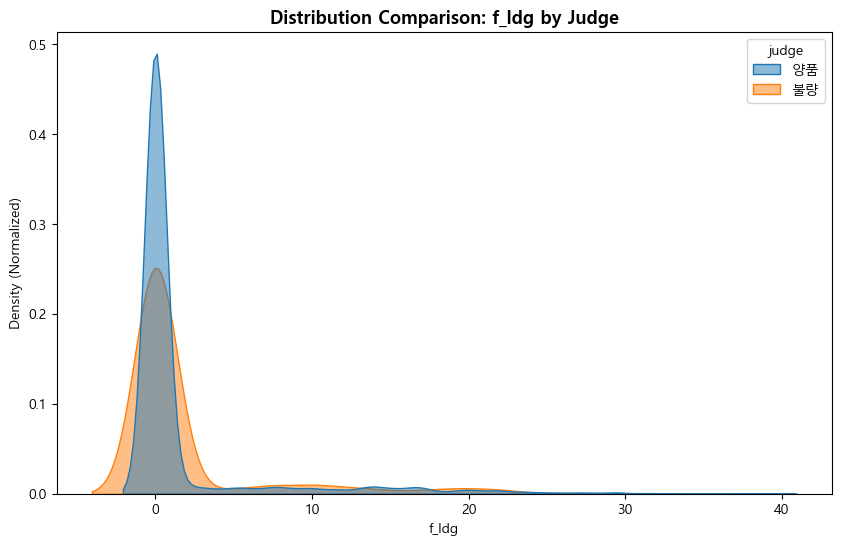

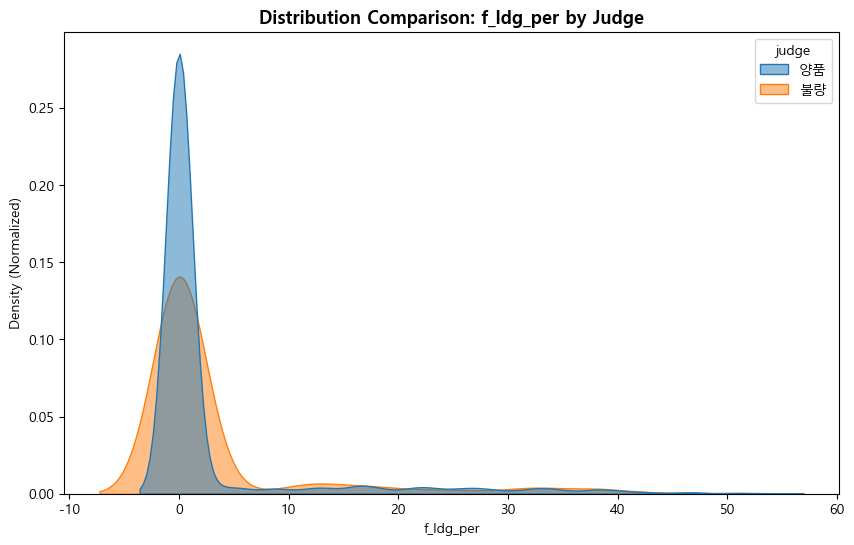

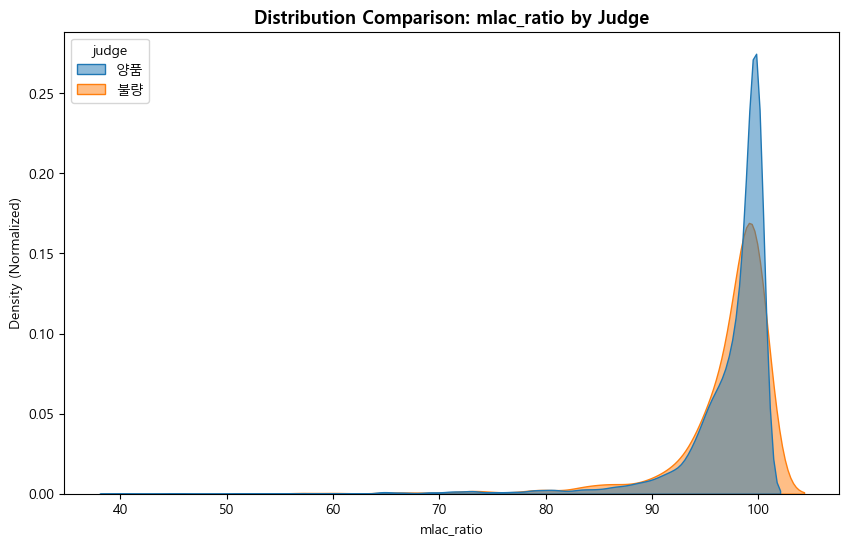

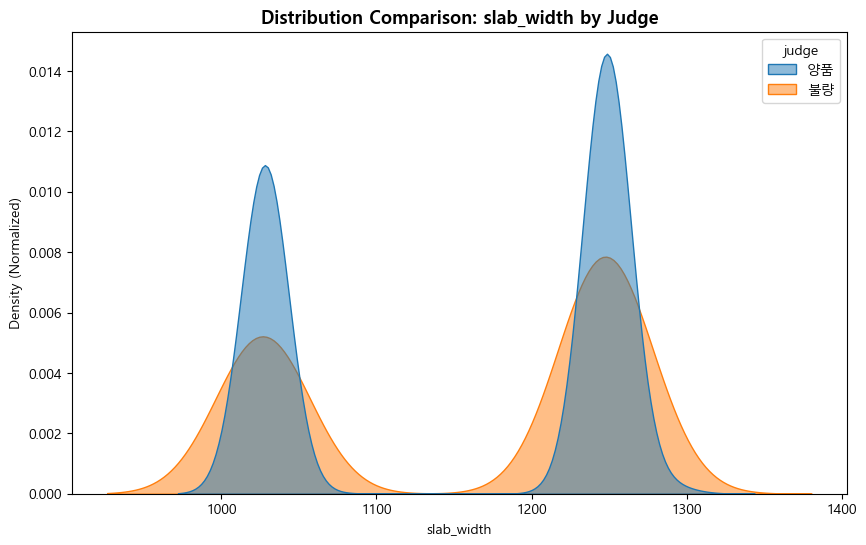

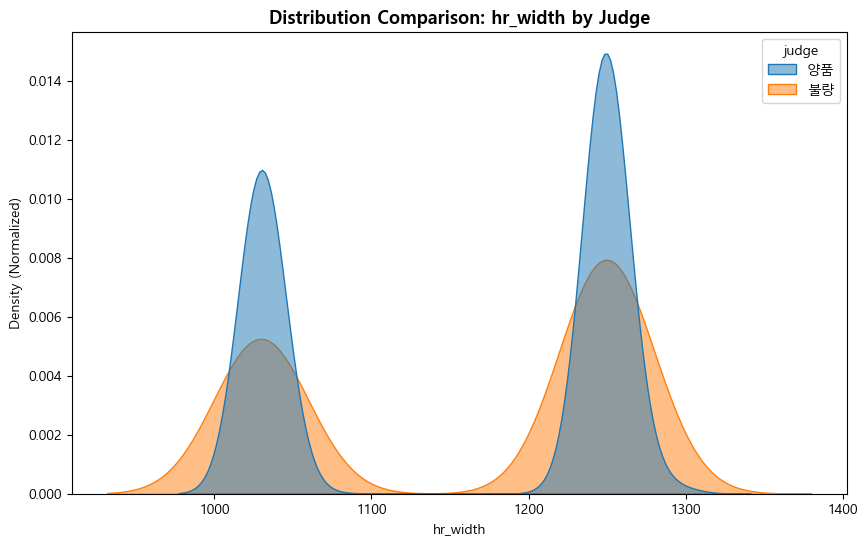

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 변수 리스트 정의
continuous_vars = [
    'rm4_temp', 'f_heat_speed', 'f_jangip_temp', 'process_delay_time1', 
    'f_pre_temp', 'f_sock_interval', 'f_heat_variable', 'f_total_time', 
    'ap_line_speed', 'ap_thick', 'process_delay_time2', 'f_sock_temp', 
    'f_ldg', 'f_ldg_per', 'mlac_ratio', 'slab_width', 'hr_width'
]

# 2. For문을 이용한 개별 시각화
for var in continuous_vars:
    plt.figure(figsize=(10, 6))
    
    # KDE Plot 그리기
    # hue='judge': 양품/불량 구분
    # fill=True: 곡선 아래 색 채우기
    # common_norm=False: 각 그룹의 합계를 1로 정규화 (데이터 불균형 해결 핵심 옵션)
    sns.kdeplot(data=final_df, x=var, hue='judge', fill=True, 
                common_norm=False, alpha=0.5)
    
    # 제목 및 라벨 설정
    plt.title(f'Distribution Comparison: {var} by Judge', fontsize=13, fontweight='bold')
    plt.xlabel(var)
    plt.ylabel('Density (Normalized)')
    
    # 그래프 출력 및 메모리 해제
    plt.show()
    plt.close()

hr_thick_group 별 eda

<Axes: xlabel='furnace_no', ylabel='count'>

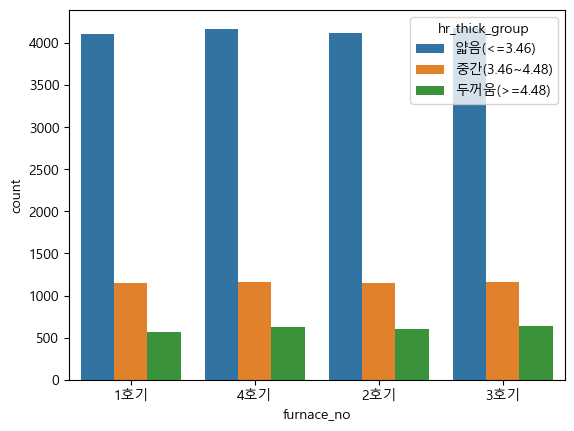

In [ ]:
sns.countplot(x="furnace_no", hue="hr_thick_group", data=final_df)

<Axes: xlabel='sm_plant', ylabel='count'>

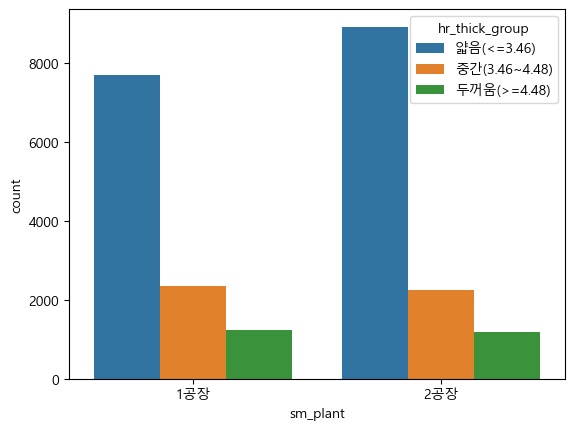

In [ ]:
sns.countplot(x="sm_plant", hue="hr_thick_group", data=final_df)

<Axes: xlabel='f_jangip_gubun', ylabel='count'>

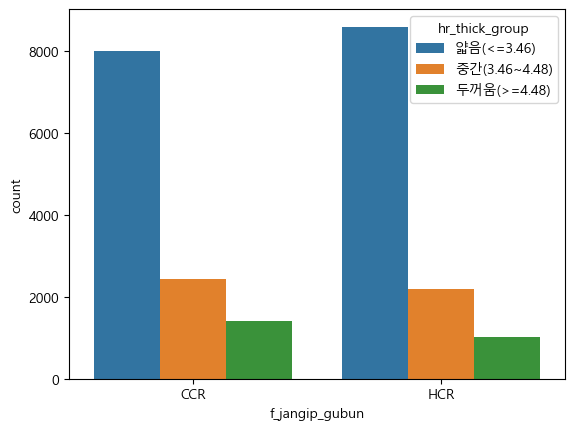

In [ ]:
sns.countplot(x="f_jangip_gubun", hue="hr_thick_group", data=final_df)

<Axes: xlabel='steel_usage', ylabel='count'>

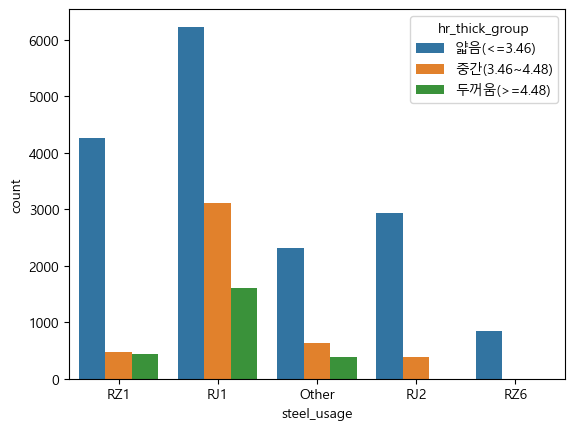

In [ ]:
sns.countplot(x="steel_usage", hue="hr_thick_group", data=final_df)

<Axes: xlabel='ap_plant', ylabel='count'>

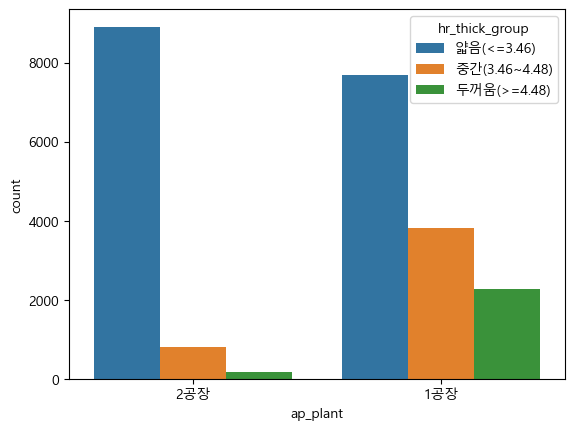

In [ ]:
sns.countplot(x="ap_plant", hue="hr_thick_group", data=final_df)

2공장의 전체 불량률이 3.1%로 높다는 것은, 결국 2공장에서 만드는 '얇음' 규격 제품들이 전체 불량률을 끌어올리고 있다

2공장의 설비 특성이나 공정 조건이 얇은 판을 뽑아낼 때 불안정할 가능성이 존재

--- [얇음(<=3.46)] 구간에서의 공장별 불량률 분석 ---
          전체 생산량(얇음)  불량 개수    불량률(%)
ap_plant                             
1공장             7689    181  2.354012
2공장             8906    239  2.683584


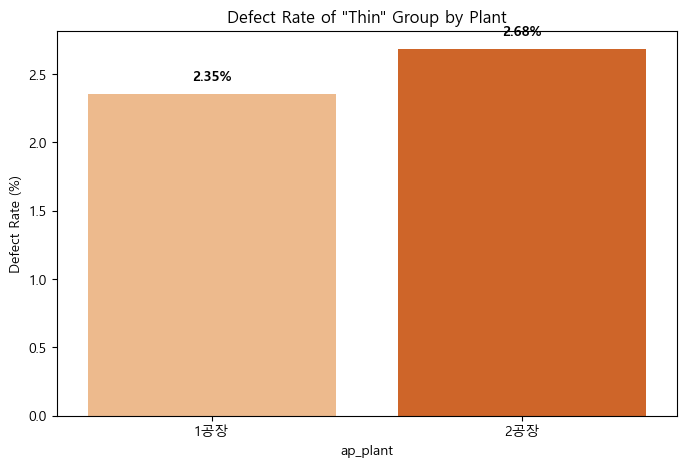

In [ ]:
import pandas as pd

# 1. '얇음' 구간 데이터만 필터링
thin_df = final_df[final_df['hr_thick_group'] == '얇음(<=3.46)'].copy()

# 2. 공장별 양품/불량 빈도 계산 (교차표)
# judge 컬럼의 값이 '불량', '양품' 형태라고 가정합니다. 
# 만약 0, 1 형태라면 그에 맞춰 결과가 나옵니다.
thin_cross = pd.crosstab(thin_df['ap_plant'], thin_df['judge'])

# 3. 불량률(%) 계산 (행별로 비율 계산 후 100 곱하기)
# '불량' 컬럼 명칭이 다를 경우(예: 1) 수정해서 사용하세요.
thin_defect_rate = (thin_cross['불량'] / thin_cross.sum(axis=1)) * 100

# 결과 출력용 데이터프레임 정리
result_df = pd.DataFrame({
    '전체 생산량(얇음)': thin_cross.sum(axis=1),
    '불량 개수': thin_cross['불량'],
    '불량률(%)': thin_defect_rate
})

print("--- [얇음(<=3.46)] 구간에서의 공장별 불량률 분석 ---")
print(result_df)

# 4. 시각화 (간단한 막대 그래프)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(x=result_df.index, y=result_df['불량률(%)'], palette='Oranges')
plt.title('Defect Rate of "Thin" Group by Plant')
plt.ylabel('Defect Rate (%)')
for i, v in enumerate(result_df['불량률(%)']):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.show()

<Axes: xlabel='ap_shift', ylabel='count'>

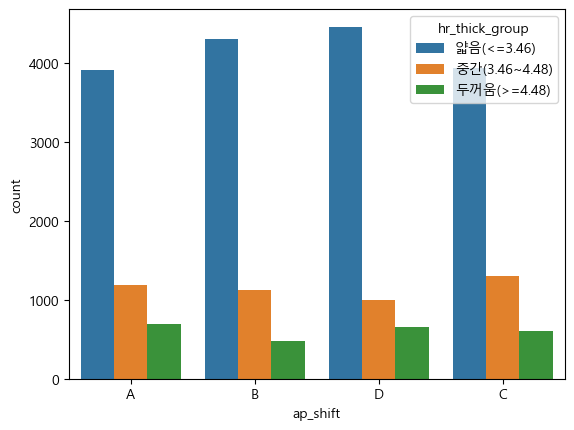

In [ ]:
sns.countplot(x="ap_shift", hue="hr_thick_group", data=final_df)

<Axes: xlabel='slab_grind', ylabel='count'>

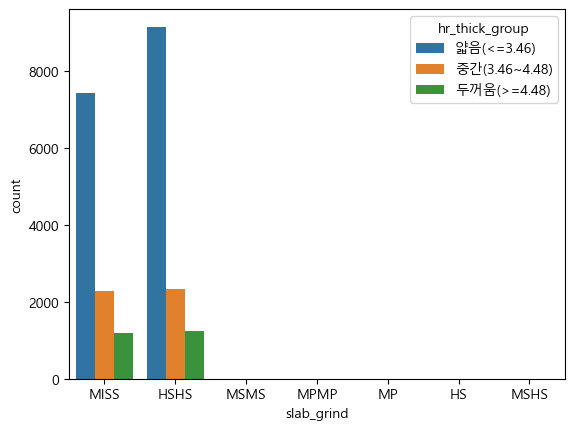

In [ ]:
sns.countplot(x="slab_grind", hue="hr_thick_group", data=final_df)

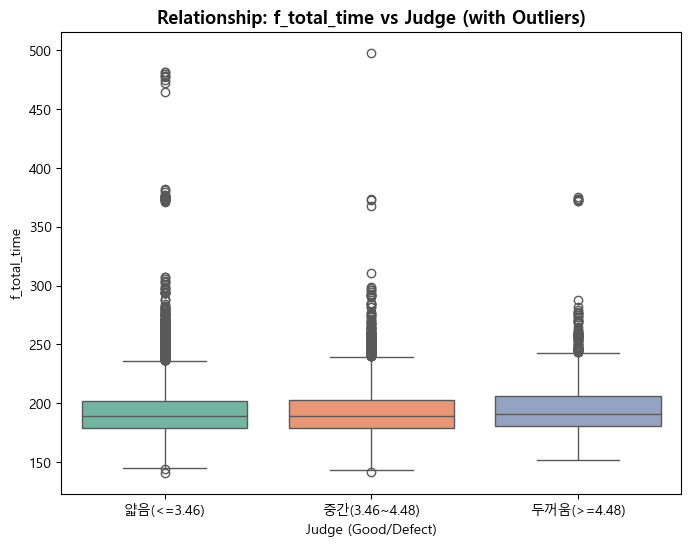

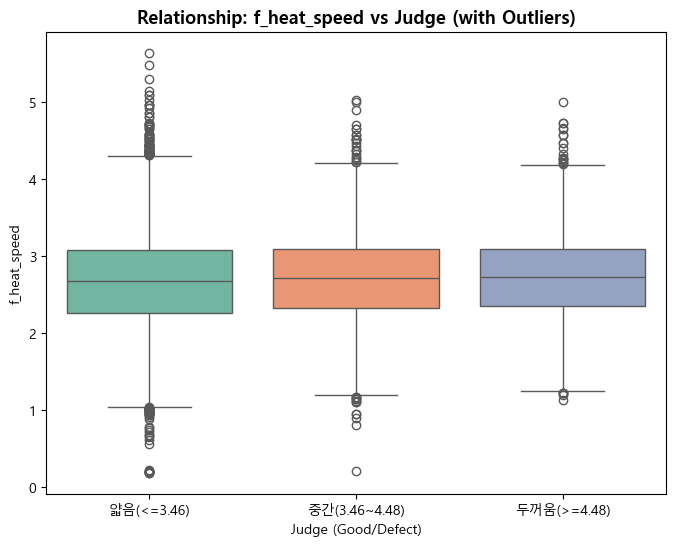

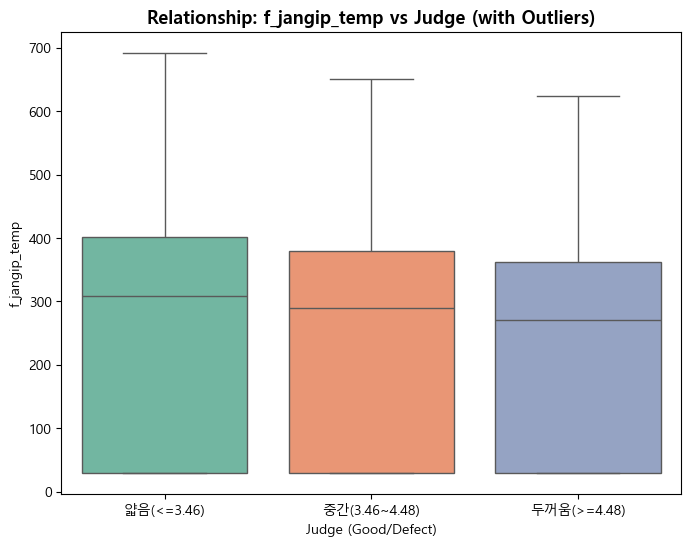

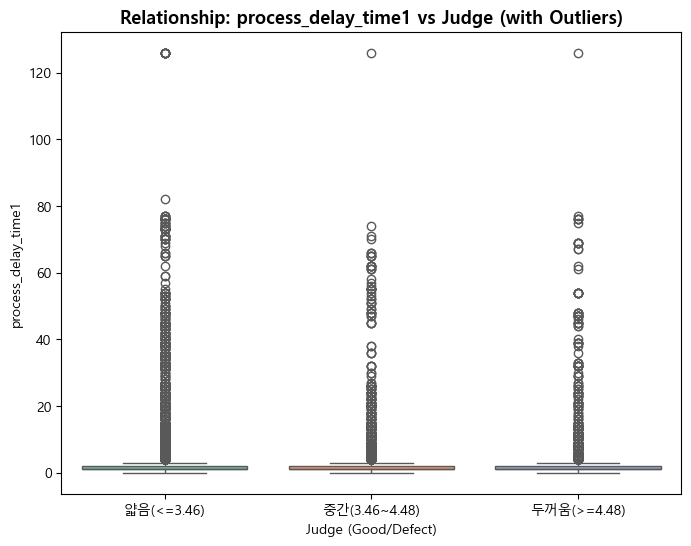

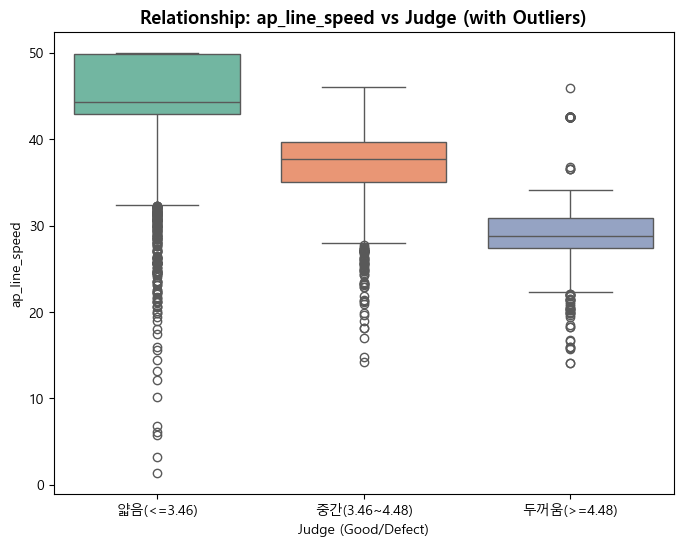

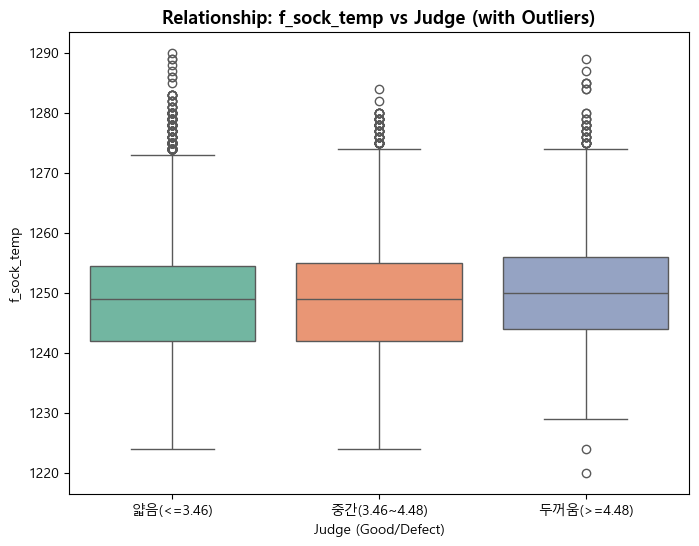

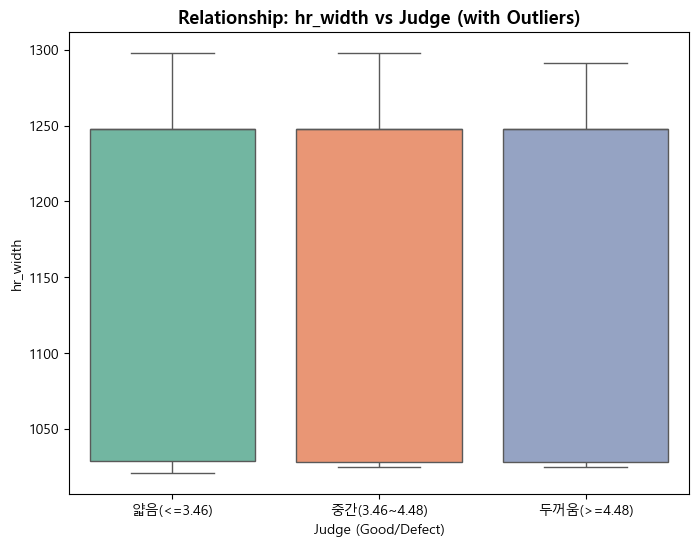

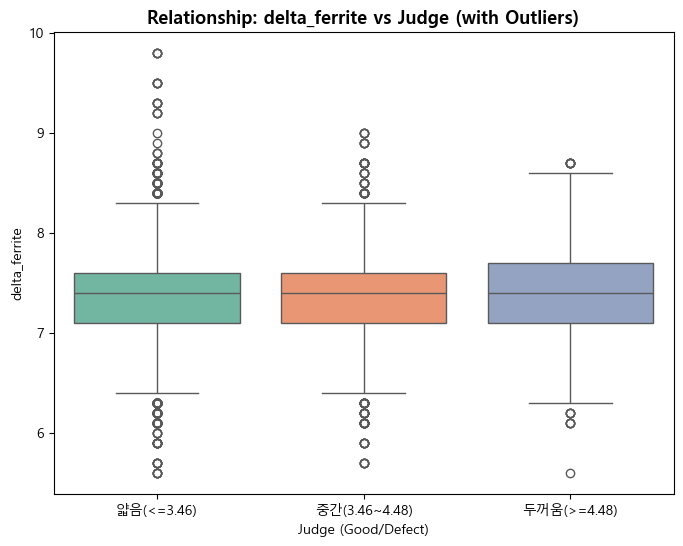

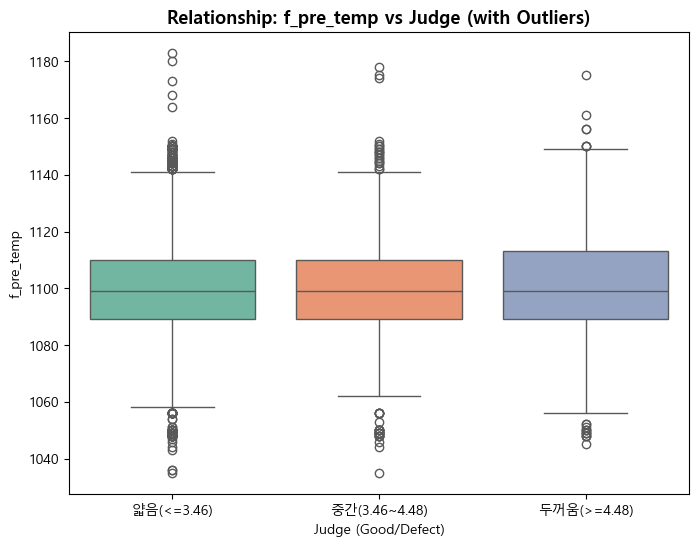

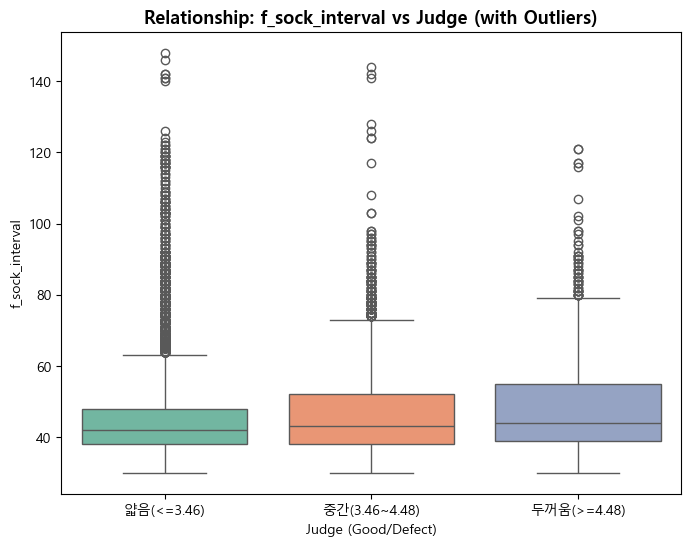

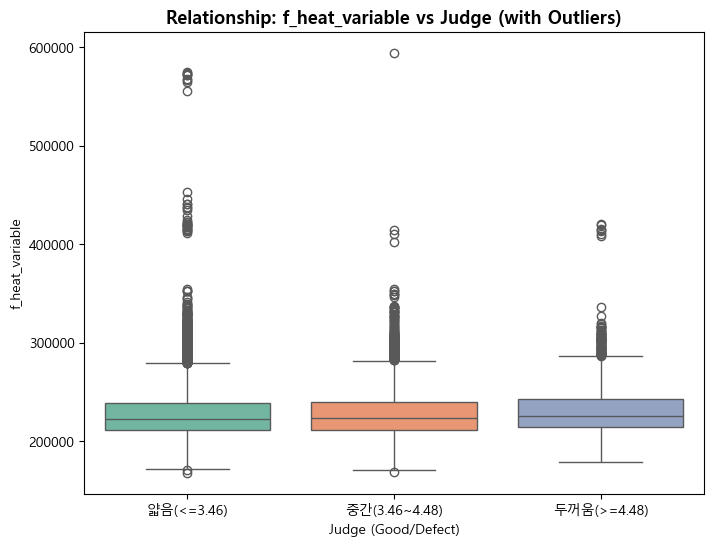

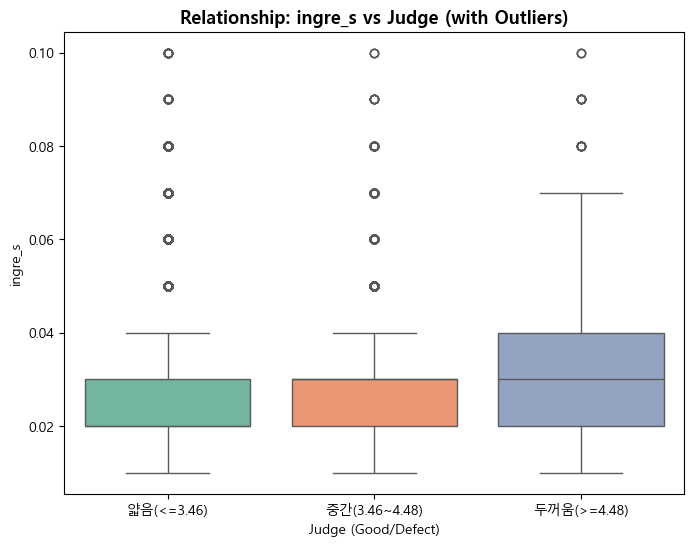

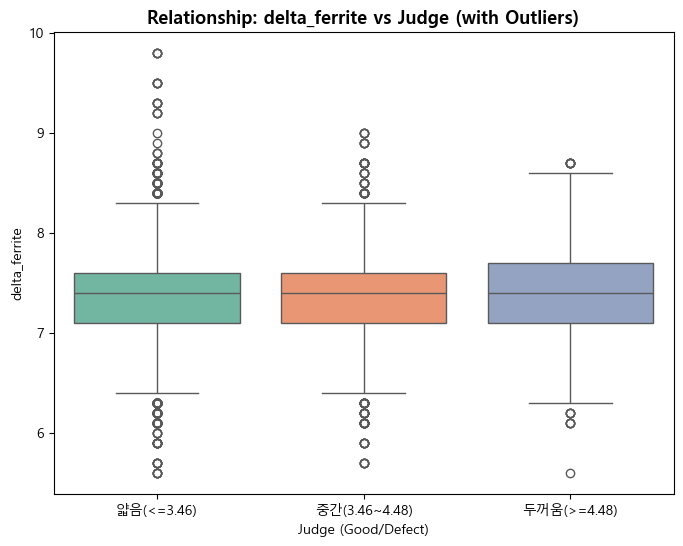

In [ ]:
# 1. 변수 리스트 정의
continuous_vars = [
    'f_total_time','f_heat_speed', 'f_jangip_temp', 'process_delay_time1',
    'ap_line_speed', 'f_sock_temp',  'hr_width', 'delta_ferrite',
    'f_pre_temp', 'f_sock_interval', 'f_heat_variable', 'ingre_s', 'delta_ferrite'
]

# 2. For문을 이용한 개별 시각화 (하나씩 차례대로 출력)
for var in continuous_vars:
    # 매 루프마다 새로운 도화지 생성
    plt.figure(figsize=(8, 6))
    
    # 이상치를 포함한 순수 박스플롯 (showfliers=True가 기본값입니다)
    sns.boxplot(x='hr_thick_group', y=var, data=final_df, palette='Set2')
    
    # 제목 및 라벨 설정
    plt.title(f'Relationship: {var} vs Judge (with Outliers)', fontsize=13, fontweight='bold')
    plt.xlabel('Judge (Good/Defect)')
    plt.ylabel(var)
    
    # 그래프 출력 후 다음 루프를 위해 메모리 해제
    plt.show()
    plt.close() # 리소스 관리를 위해 닫아주는 것이 좋습니다.

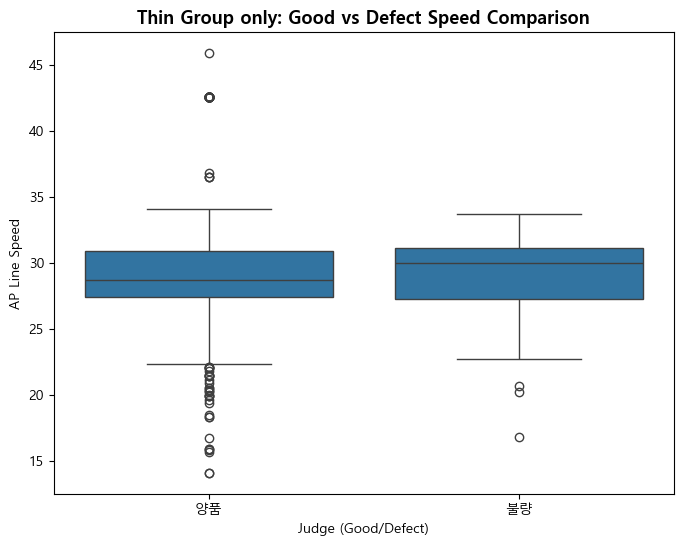

In [ ]:
# 1. '두꺼움' 구간 데이터만 필터링
thin_df = final_df[final_df['hr_thick_group'] == '두꺼움(>=4.48)'].copy()

# 2. '두꺼움' 구간 내에서 판정(judge)별 소둔산세속도(ap_line_speed) 비교
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# hue='judge' 옵션을 통해 양품과 불량을 나란히 비교합니다.
sns.boxplot(x='judge', y='ap_line_speed', data=thin_df)

plt.title('Thin Group only: Good vs Defect Speed Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Judge (Good/Defect)')
plt.ylabel('AP Line Speed')
plt.show()

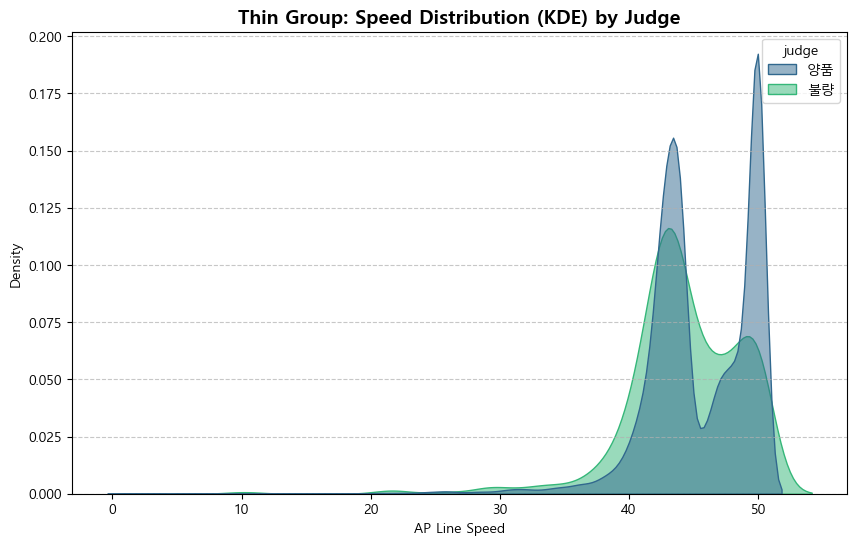

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. '두꺼움' 구간 데이터 필터링 (기존 동일)
thin_df = final_df[final_df['hr_thick_group'] == '두꺼움(>=4.48)'].copy()

# 2. KDE Plot 시각화
plt.figure(figsize=(10, 6))

# fill=True: 곡선 아래 색상 채움
# common_norm=False: 각 그룹(양품/불량)의 전체 면적을 각각 1로 계산하여 비율 차이를 보정
sns.kdeplot(data=thin_df, x='ap_line_speed', hue='judge', fill=True, common_norm=False, palette='viridis', alpha=0.5)

plt.title('Thin Group: Speed Distribution (KDE) by Judge', fontsize=14, fontweight='bold')
plt.xlabel('AP Line Speed')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

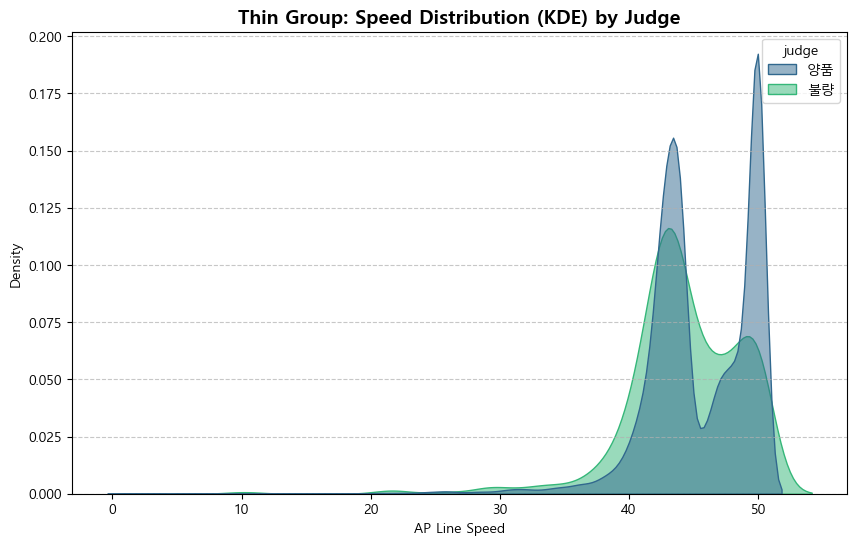

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. '두꺼움' 구간 데이터 필터링 (기존 동일)
thin_df = final_df[final_df['hr_thick_group'] == '얇음(<=3.46)'].copy()

# 2. KDE Plot 시각화
plt.figure(figsize=(10, 6))

# fill=True: 곡선 아래 색상 채움
# common_norm=False: 각 그룹(양품/불량)의 전체 면적을 각각 1로 계산하여 비율 차이를 보정
sns.kdeplot(data=thin_df, x='ap_line_speed', hue='judge', fill=True, common_norm=False, palette='viridis', alpha=0.5)

plt.title('Thin Group: Speed Distribution (KDE) by Judge', fontsize=14, fontweight='bold')
plt.xlabel('AP Line Speed')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# 얇음 구간 내 양품과 불량의 속도 데이터 추출
good_speed = thin_df[thin_df['judge'] == '양품']['ap_line_speed']
defect_speed = thin_df[thin_df['judge'] == '불량']['ap_line_speed']

# 비모수 검정 실시
stat, p_val = mannwhitneyu(good_speed, defect_speed)
print(f"p-value: {p_val:.4f}")

p-value: 0.0000


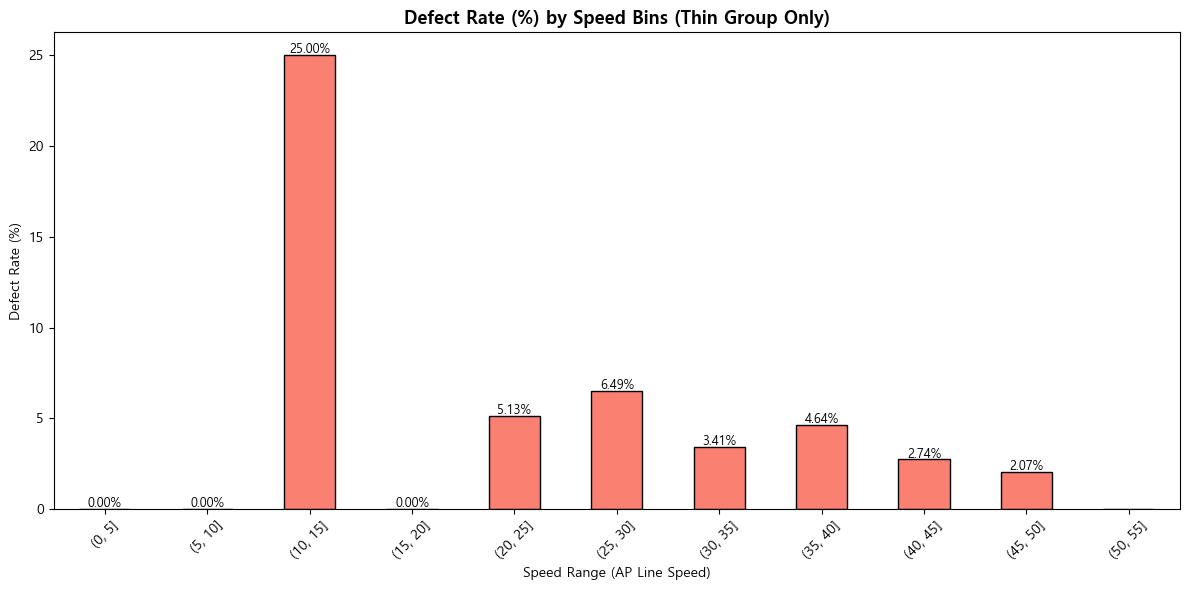

In [ ]:
import pandas as pd

# 1. 속도를 구간(Bin)으로 나누기 (5단위로 나눈다고 가정)
bins = list(range(0, 60, 5)) 
thin_df['speed_bin'] = pd.cut(thin_df['ap_line_speed'], bins=bins)

# 2. 구간별 불량률 계산
# judge가 '불량'인 경우를 1로 변환해서 평균을 내면 그게 바로 불량률입니다.
thin_df['target_num'] = thin_df['judge'].apply(lambda x: 1 if x == '불량' else 0)
bin_analysis = thin_df.groupby('speed_bin')['target_num'].mean() * 100

# 3. 시각화
plt.figure(figsize=(12, 6))
bin_analysis.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Defect Rate (%) by Speed Bins (Thin Group Only)', fontsize=13, fontweight='bold')
plt.xlabel('Speed Range (AP Line Speed)')
plt.ylabel('Defect Rate (%)')
plt.xticks(rotation=45)

# 바 위에 수치 표시
for i, v in enumerate(bin_analysis):
    if not pd.isna(v):
        plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

--- '두꺼움' 그룹 분석 시작 (데이터 수: 2426건) ---


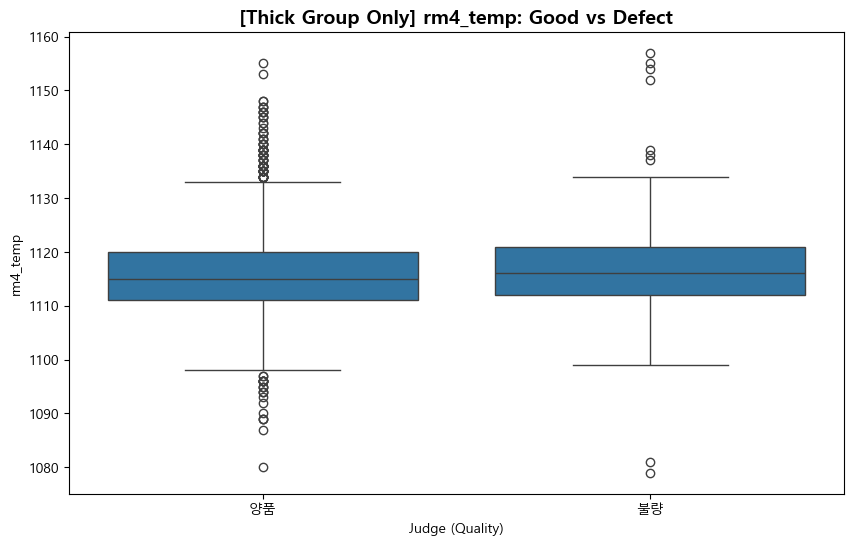

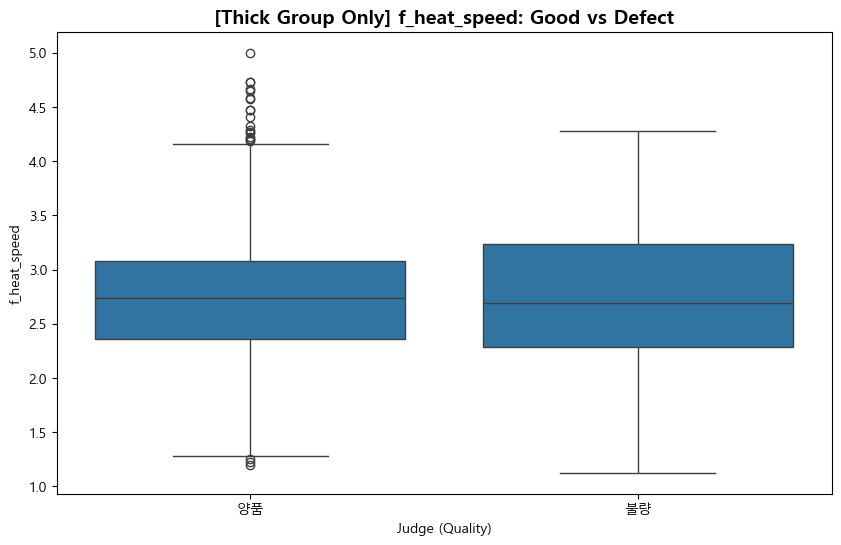

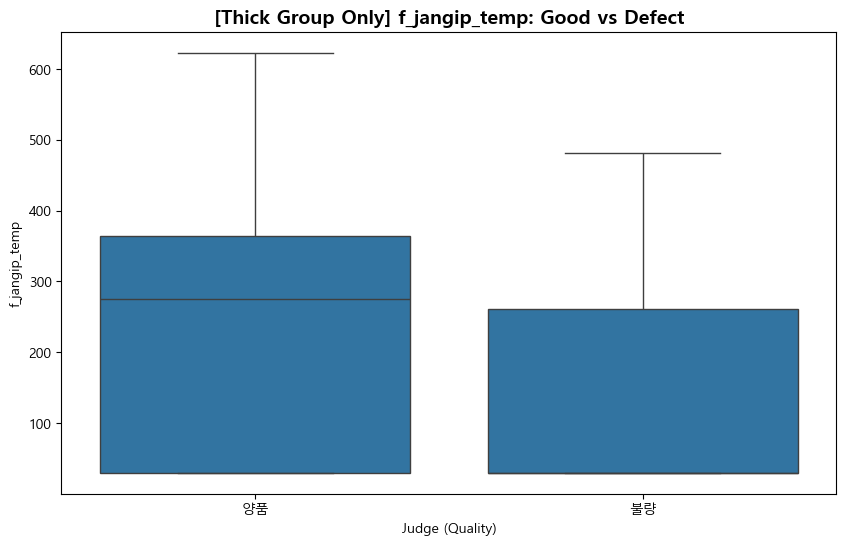

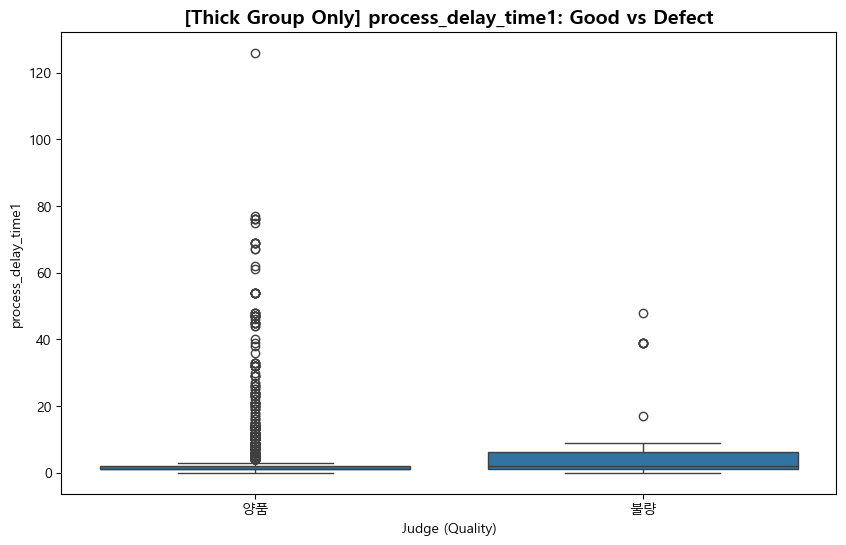

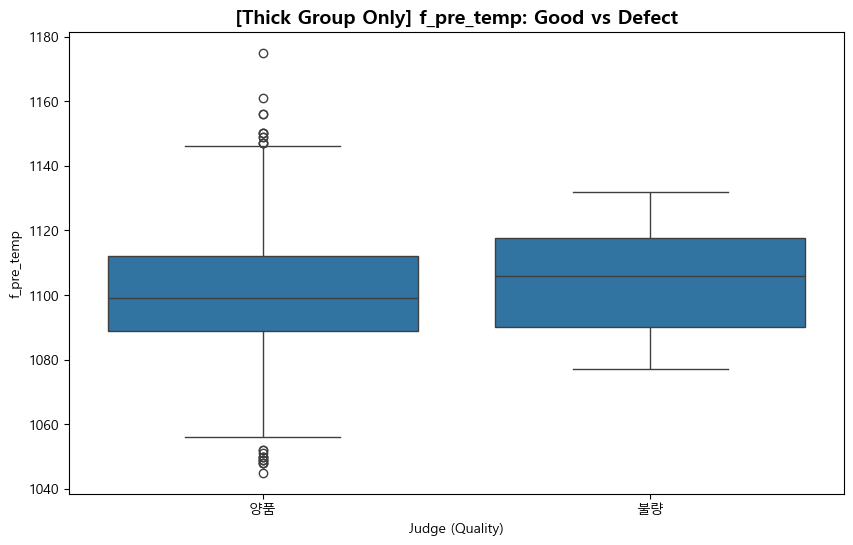

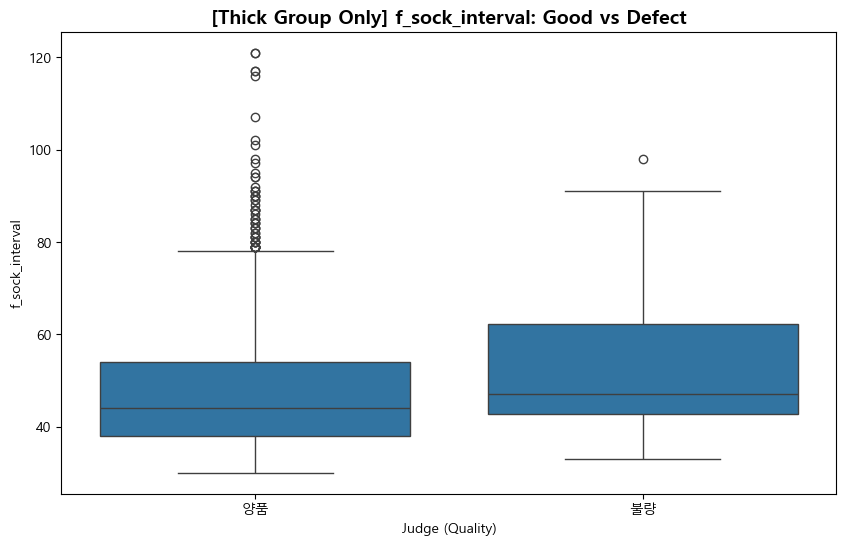

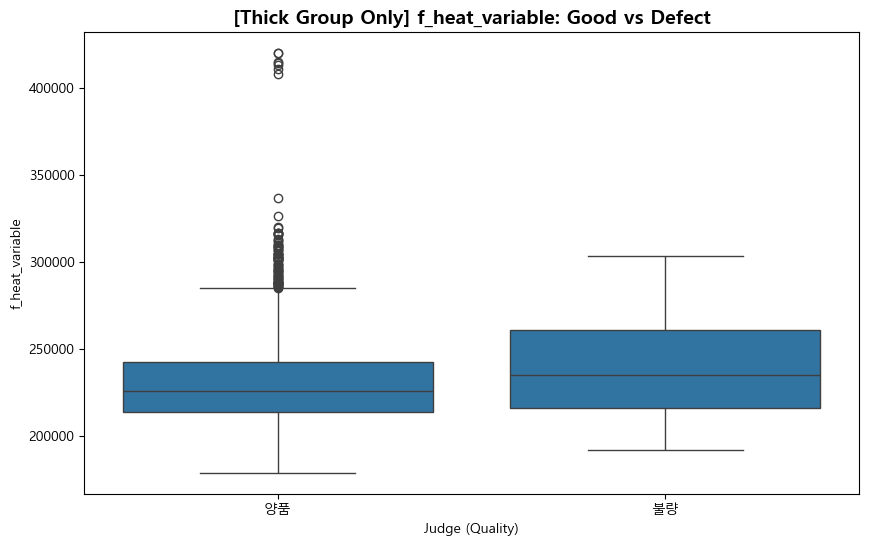

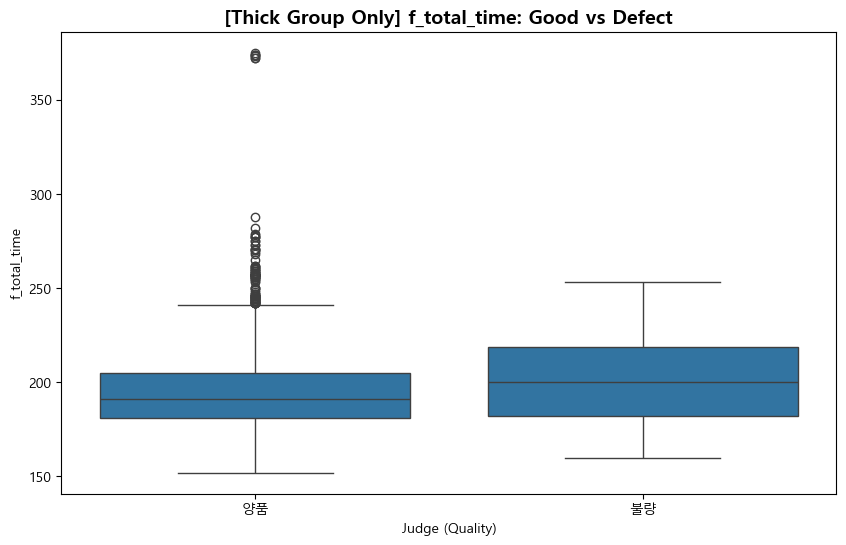

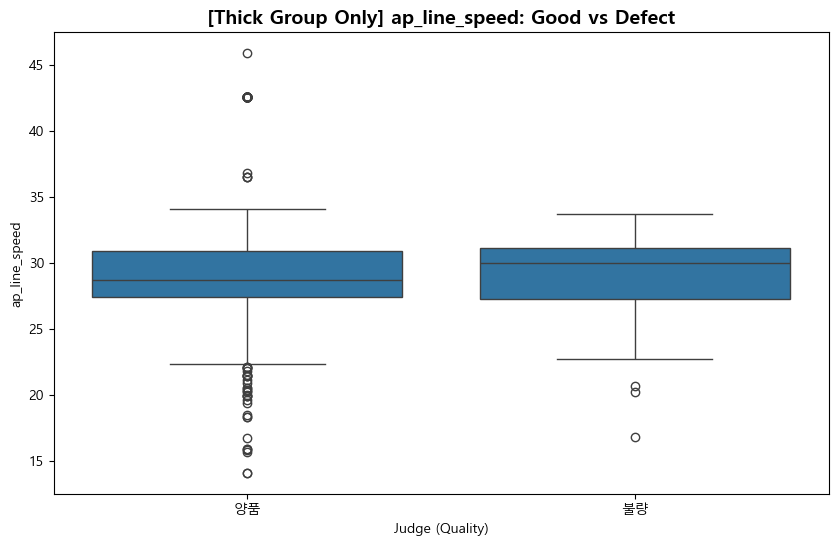

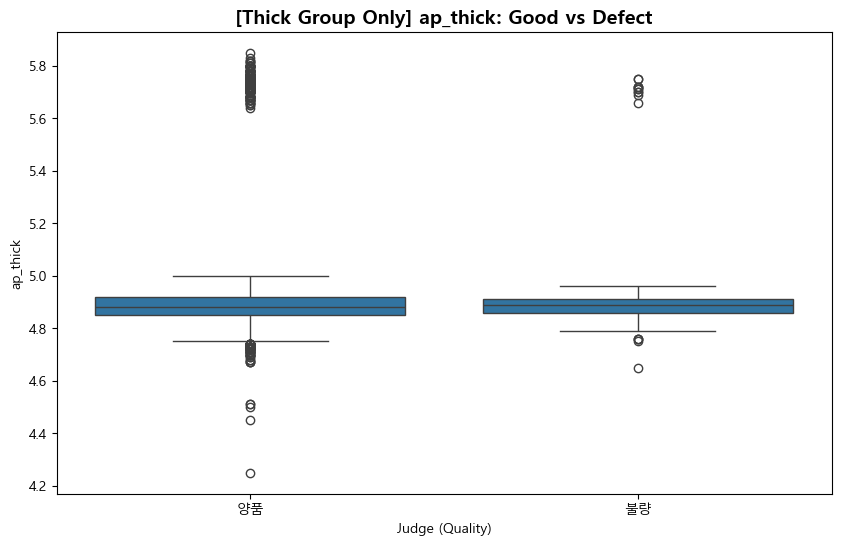

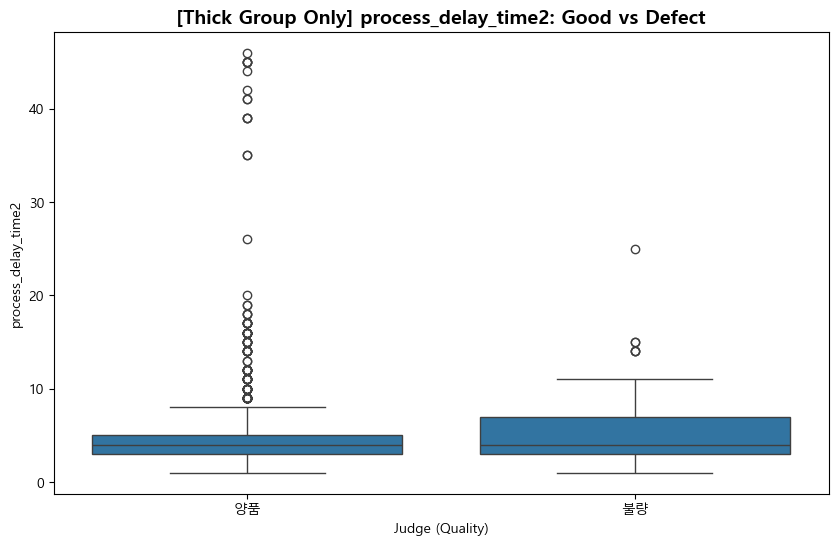

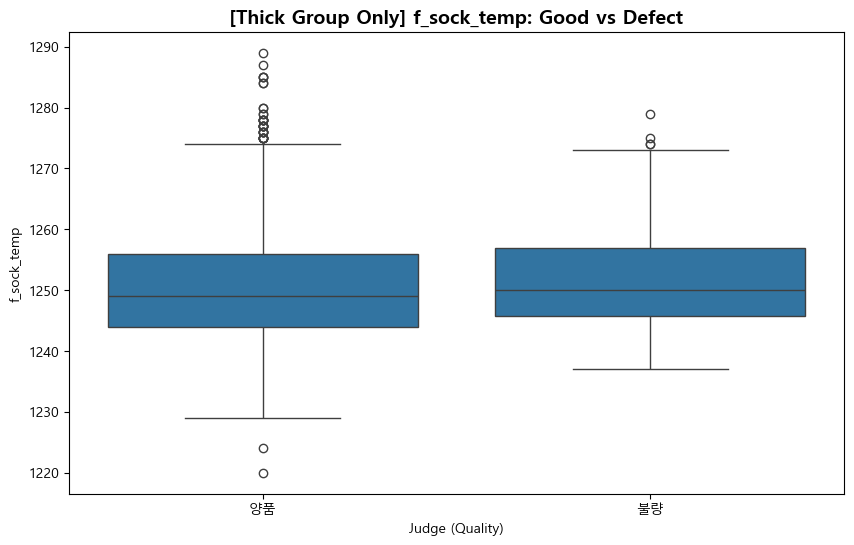

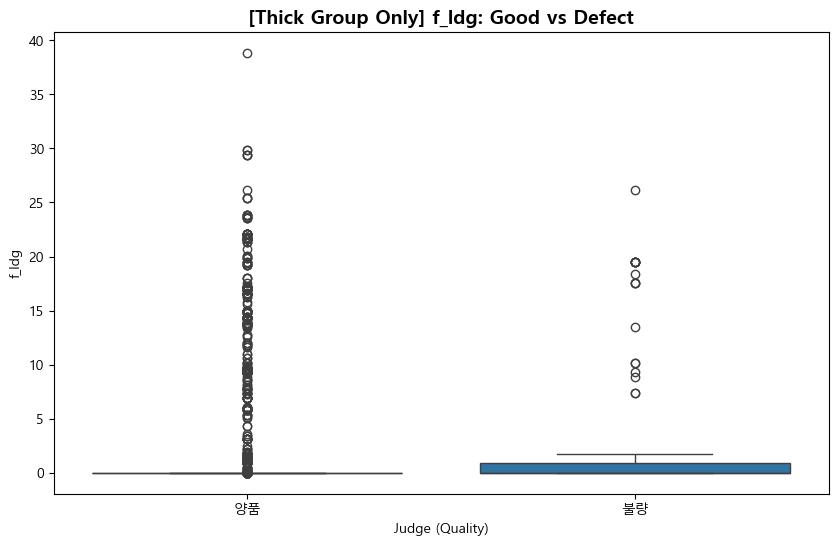

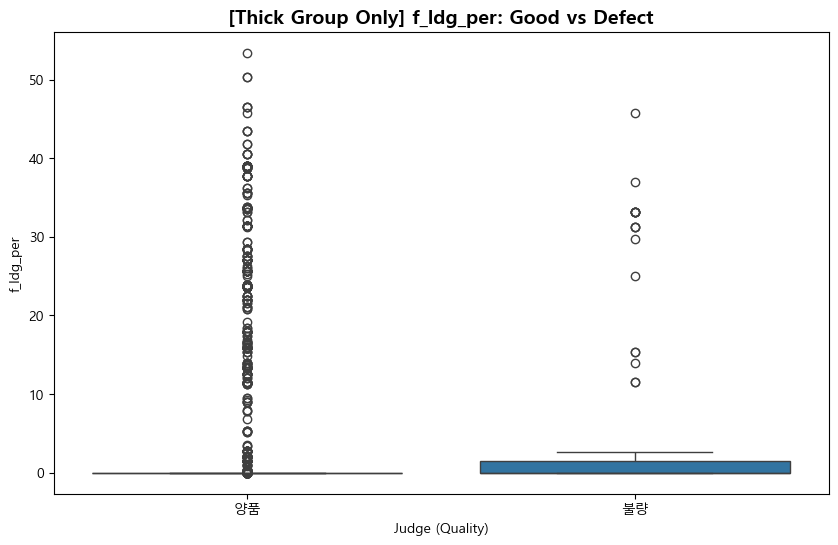

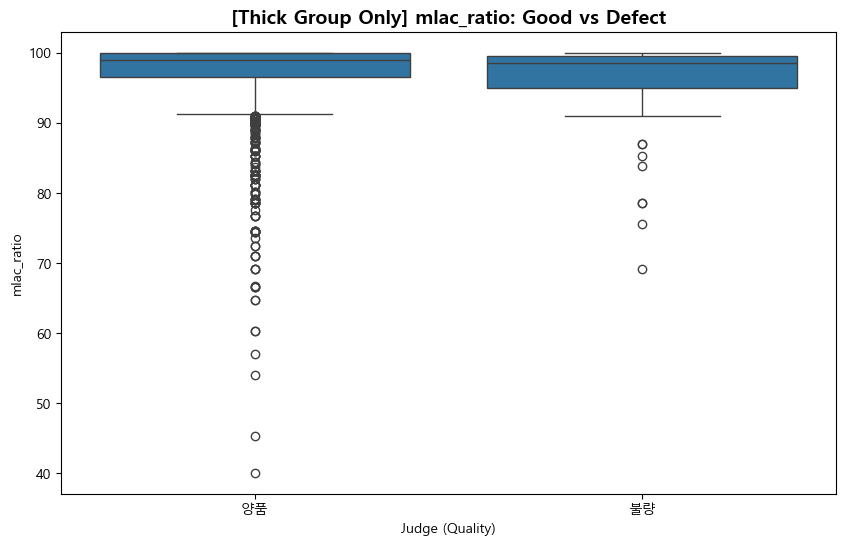

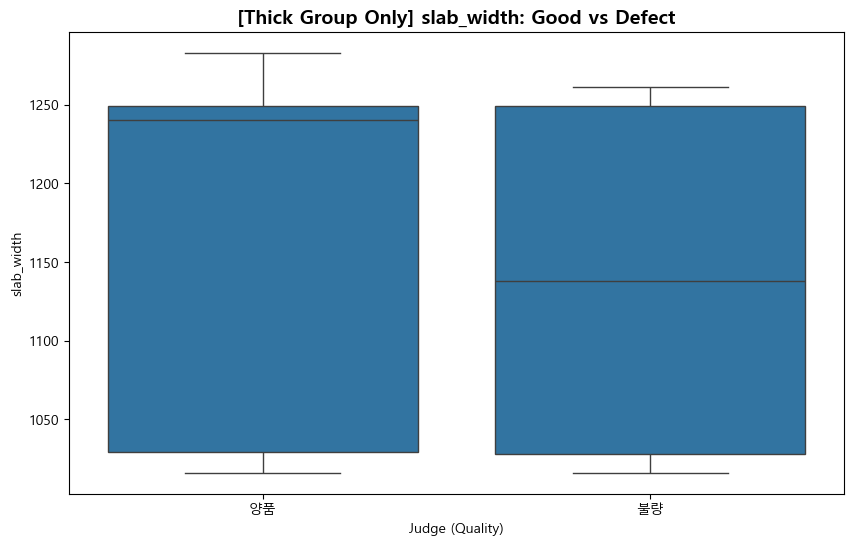

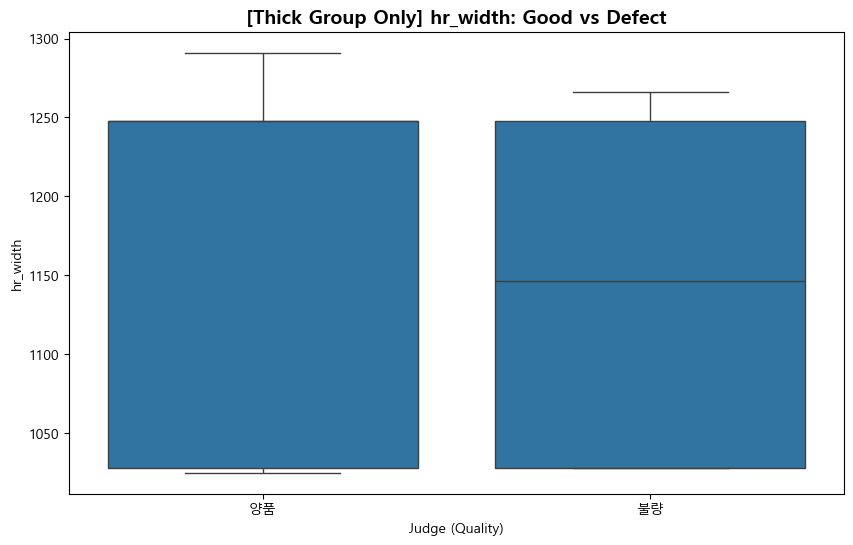

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. '두꺼움' 구간 데이터만 필터링 (파일명/변수명은 환경에 맞게 수정)
# 보통 '두꺼움(>=4.48)' 등으로 저장되어 있으므로 str.contains를 쓰면 안전합니다.
thick_df = final_df[final_df['hr_thick_group'].str.contains('두꺼움')].copy()

# 2. 분석할 연속형 변수 리스트
continuous_vars = [
    'rm4_temp', 'f_heat_speed', 'f_jangip_temp', 'process_delay_time1', 
    'f_pre_temp', 'f_sock_interval', 'f_heat_variable', 'f_total_time', 
    'ap_line_speed', 'ap_thick', 'process_delay_time2', 'f_sock_temp', 
    'f_ldg', 'f_ldg_per', 'mlac_ratio', 'slab_width', 'hr_width'
]

# 3. For문을 이용한 변수별 개별 시각화
print(f"--- '두꺼움' 그룹 분석 시작 (데이터 수: {len(thick_df)}건) ---")

for var in continuous_vars:
    plt.figure(figsize=(10, 6))
    
    # 이상치를 포함한 박스플롯으로 양품/불량 비교
    sns.boxplot(x='judge', y=var, data=thick_df)
    
    plt.title(f'[Thick Group Only] {var}: Good vs Defect', fontsize=14, fontweight='bold')
    plt.xlabel('Judge (Quality)')
    plt.ylabel(var)
    
    plt.show()
    plt.close()

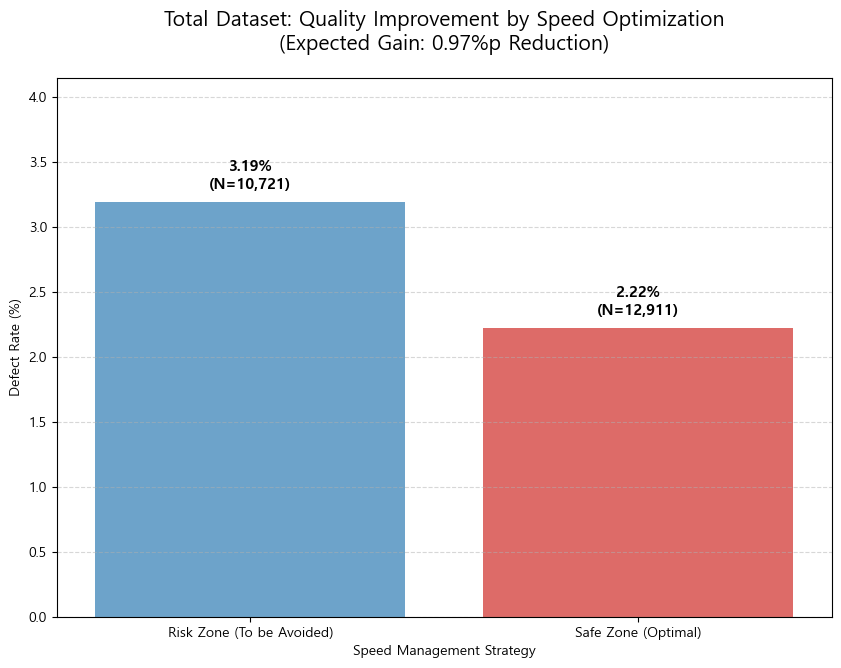

--- [전체 데이터] 속도 최적화 분석 결과 ---
1. 안전 구간(Safe) 운전 시 불량률: 2.22%
2. 위험 구간(Risk) 운전 시 불량률: 3.19%
3. 위험 구간 회피 시 기대 효과: 불량률 0.97%p 개선


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전체 데이터 복사 및 전처리
df_all = final_df.copy()
df_all['is_defect'] = (df_all['judge'] == '불량').astype(int)

# 2. 사용자 정의 위험 구간(Risk Zone) 설정 (전체 데이터 적용)
# 조건: 40 미만 또는 (44 이상 48 이하)
risk_cond = (df_all['ap_line_speed'] < 40) | ((df_all['ap_line_speed'] >= 44) & (df_all['ap_line_speed'] <= 48))

# 3. 그룹 라벨링
df_all['speed_strategy'] = 'Safe Zone (Optimal)'
df_all.loc[risk_cond, 'speed_strategy'] = 'Risk Zone (To be Avoided)'

# 4. 그룹별 통계 계산 (불량률 및 데이터 개수)
summary = df_all.groupby('speed_strategy').agg(
    defect_rate=('is_defect', 'mean'),
    sample_size=('is_defect', 'count')
)
summary['defect_rate'] *= 100 # 백분율 변환

# 5. 시각화
plt.figure(figsize=(10, 7))
colors = ['#5DA5DA', '#F15854'] # Safe: Blue, Risk: Red
ax = sns.barplot(x=summary.index, y=summary['defect_rate'], palette=colors)

# 막대 위에 불량률 및 (불량수/전체수) 표시
for i, v in enumerate(summary['defect_rate']):
    n = summary['sample_size'].iloc[i]
    ax.text(i, v + 0.1, f'{v:.2f}%\n(N={n:,})', ha='center', fontsize=11, fontweight='bold')

# 개선 효과(Improvement) 계산
improvement = summary.loc['Risk Zone (To be Avoided)', 'defect_rate'] - summary.loc['Safe Zone (Optimal)', 'defect_rate']

plt.title(f'Total Dataset: Quality Improvement by Speed Optimization\n(Expected Gain: {improvement:.2f}%p Reduction)', fontsize=15, pad=20)
plt.ylabel('Defect Rate (%)')
plt.xlabel('Speed Management Strategy')
plt.ylim(0, summary['defect_rate'].max() * 1.3) # 여유 공간 확보
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# 6. 결과 리포트 출력
print(f"--- [전체 데이터] 속도 최적화 분석 결과 ---")
print(f"1. 안전 구간(Safe) 운전 시 불량률: {summary.loc['Safe Zone (Optimal)', 'defect_rate']:.2f}%")
print(f"2. 위험 구간(Risk) 운전 시 불량률: {summary.loc['Risk Zone (To be Avoided)', 'defect_rate']:.2f}%")
print(f"3. 위험 구간 회피 시 기대 효과: 불량률 {improvement:.2f}%p 개선")

### 구간별 불량률 계산

In [41]:
import pandas as pd
import numpy as np

# 1. 구간 정의 (이미지 분석 내용 반영)
# Risk Zone: 40 미만 또는 44 ~ 48 사이
def categorize_speed(speed):
    if speed < 1246:
        return 'Risk Zone'
    else:
        return 'Safe Zone'

# 2. 데이터 분류 적용
final_df['zone'] = final_df['f_sock_temp'].apply(categorize_speed)

# 3. 구간별 불량률(Bad Rate) 계산
# '불량'이 1, '양품'이 0인 수치 데이터가 필요합니다. 
# (만약 텍스트라면 변환 과정 필요: df['is_bad'] = np.where(df['judge'] == '불량', 1, 0))
analysis = final_df.groupby('zone')['judge'].value_counts(normalize=True).unstack()

# 불량률만 추출 (불량 컬럼이 '불량' 또는 1이라고 가정)
bad_rate_by_zone = analysis['불량'] * 100

print("### 구간별 불량률 분석 결과 ###")
print(bad_rate_by_zone)
print("-" * 30)

# 4. 개선 효과 시뮬레이션 결과 출력
risk_zone_rate = bad_rate_by_zone['Risk Zone']
safe_zone_rate = bad_rate_by_zone['Safe Zone']
improvement = risk_zone_rate - safe_zone_rate

print(f"1. 위험 구간(Risk Zone) 불량률: {risk_zone_rate:.2f}%")
print(f"2. 안전 구간(Safe Zone) 불량률: {safe_zone_rate:.2f}%")
print(f"3. 개선 기대 효과: 속도 제어 시 불량률 약 {improvement:.2f}%p 감소 가능")

### 구간별 불량률 분석 결과 ###
zone
Risk Zone    2.427239
Safe Zone    2.803231
Name: 불량, dtype: float64
------------------------------
1. 위험 구간(Risk Zone) 불량률: 2.43%
2. 안전 구간(Safe Zone) 불량률: 2.80%
3. 개선 기대 효과: 속도 제어 시 불량률 약 -0.38%p 감소 가능


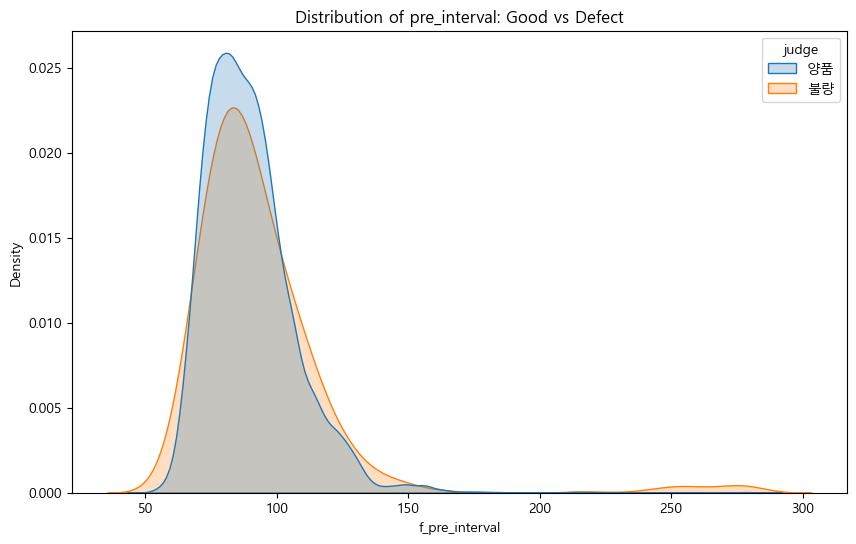

In [ ]:
plt.figure(figsize=(10, 6))
# common_norm=False를 써야 개수 차이에 상관없이 모양 비교가 가능합니다.
sns.kdeplot(data=final_df, x='f_pre_interval', hue='judge', fill=True, common_norm=False)

plt.title('Distribution of pre_interval: Good vs Defect')
plt.xlabel('f_pre_interval')
plt.show()

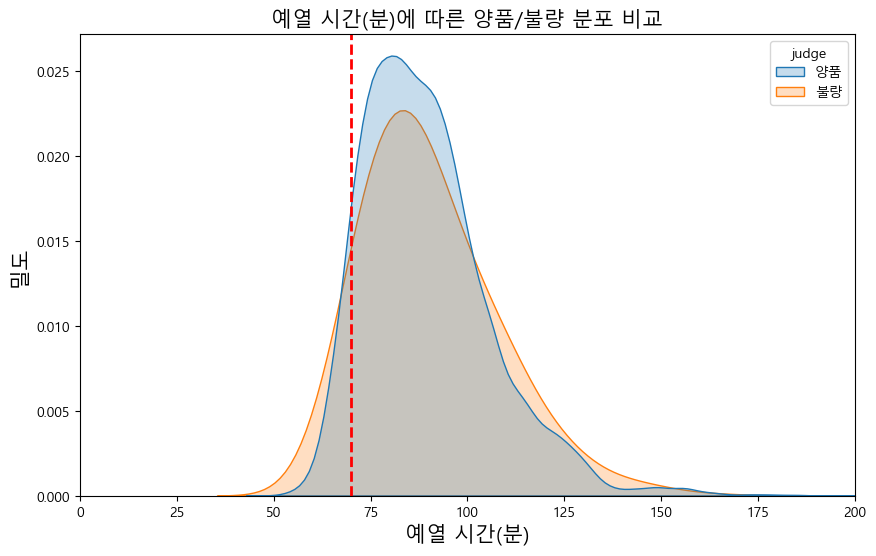

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# judge별로 색상을 나누어 밀도 함수 그리기
# common_norm=False를 설정해야 각 그룹의 전체 합을 1로 계산하여 분포 모양 비교가 쉬워집니다.
sns.kdeplot(data=final_df, x='f_pre_interval', hue='judge', fill=True, common_norm=False)
plt.axvline(x=70, color='red', linestyle='--', linewidth=2)
# plt.axvline(x=170, color='red', linestyle='--', linewidth=2)

plt.title('예열 시간(분)에 따른 양품/불량 분포 비교', fontsize=15)
plt.xlabel('예열 시간(분)', fontsize=15)
plt.ylabel('밀도', fontsize=15)
plt.xlim(0, 200)
# plt.ylim(0, 0.03)

plt.show()

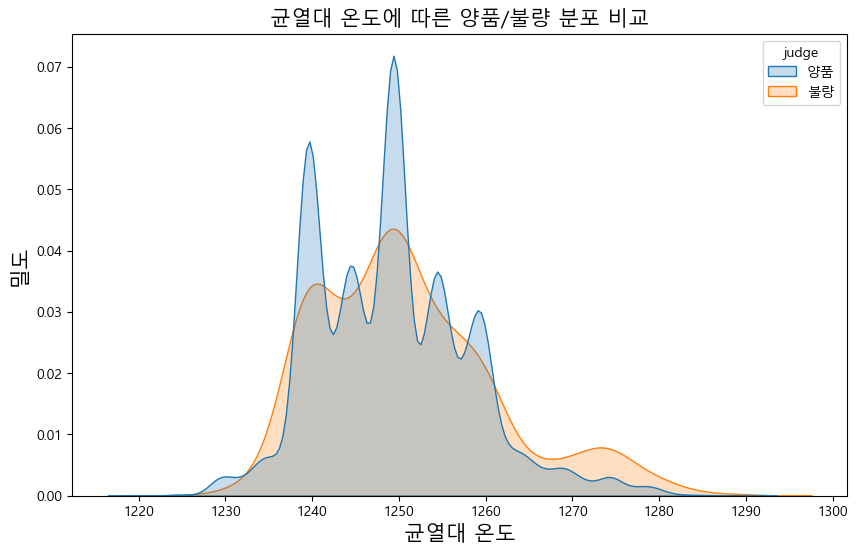

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# judge별로 색상을 나누어 밀도 함수 그리기
# common_norm=False를 설정해야 각 그룹의 전체 합을 1로 계산하여 분포 모양 비교가 쉬워집니다.
sns.kdeplot(data=final_df, x='f_sock_temp', hue='judge', fill=True, common_norm=False)
# plt.axvline(x=70, color='red', linestyle='--', linewidth=2)
# plt.axvline(x=170, color='red', linestyle='--', linewidth=2)

plt.title('균열대 온도에 따른 양품/불량 분포 비교', fontsize=15)
plt.xlabel('균열대 온도', fontsize=15)
plt.ylabel('밀도', fontsize=15)
# plt.xlim(0, 200)
# plt.ylim(0, 0.03)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. 구간 정의 (이미지 분석 내용 반영)
# Risk Zone: 40 미만 또는 44 ~ 48 사이
def categorize_speed(speed):
    if speed < 70 :
        return 'Risk Zone'
    else:
        return 'Safe Zone'

# 2. 데이터 분류 적용
final_df['zone'] = final_df['f_pre_interval'].apply(categorize_speed)

# 3. 구간별 불량률(Bad Rate) 계산
# '불량'이 1, '양품'이 0인 수치 데이터가 필요합니다. 
# (만약 텍스트라면 변환 과정 필요: df['is_bad'] = np.where(df['judge'] == '불량', 1, 0))
analysis = final_df.groupby('zone')['judge'].value_counts(normalize=True).unstack()

# 불량률만 추출 (불량 컬럼이 '불량' 또는 1이라고 가정)
bad_rate_by_zone = analysis['불량'] * 100

print("### 구간별 불량률 분석 결과 ###")
print(bad_rate_by_zone)
print("-" * 30)

# 4. 개선 효과 시뮬레이션 결과 출력
risk_zone_rate = bad_rate_by_zone['Risk Zone']
safe_zone_rate = bad_rate_by_zone['Safe Zone']
improvement = risk_zone_rate - safe_zone_rate

print(f"1. 위험 구간(Risk Zone) 불량률: {risk_zone_rate:.2f}%")
print(f"2. 안전 구간(Safe Zone) 불량률: {safe_zone_rate:.2f}%")
print(f"3. 개선 기대 효과: 속도 제어 시 불량률 약 {improvement:.2f}%p 감소 가능")

### 구간별 불량률 분석 결과 ###
zone
Risk Zone    2.231356
Safe Zone    2.695061
Name: 불량, dtype: float64
------------------------------
1. 위험 구간(Risk Zone) 불량률: 2.23%
2. 안전 구간(Safe Zone) 불량률: 2.70%
3. 개선 기대 효과: 속도 제어 시 불량률 약 -0.46%p 감소 가능


In [ ]:
import pandas as pd
import numpy as np

# 1. 구간(Bin) 설정: 5초 단위로 변경 (40초부터 310초까지)
# 5단위로 끊기 위해 step을 5로 설정합니다.
bins = np.arange(40, 315, 10) 
labels = [f"{i}-{i+10}" for i in bins[:-1]]

# 2. 구간 데이터 생성 (데이터프레임 명칭을 final_df로 유지)
final_df['interval_range'] = pd.cut(final_df['f_pre_interval'], bins=bins, labels=labels)

# 3. 구간별 통계량 집계
# 'judge' 컬럼의 '양품', '불량' 값을 기반으로 피벗 테이블 생성
summary_table = final_df.groupby('interval_range', observed=True)['judge'].value_counts().unstack(fill_value=0)

# 4. 필수 컬럼이 없을 경우를 대비해 컬럼 보정 (양품/불량이 아예 없는 구간 방지)
for col in ['양품', '불량']:
    if col not in summary_table.columns:
        summary_table[col] = 0

# 5. 수치 계산: 전체생산량 및 불량률(%)
summary_table['전체'] = summary_table['양품'] + summary_table['불량']
summary_table['불량률(%)'] = (summary_table['불량'] / summary_table['전체'] * 100).round(2)

# 6. 신뢰도 평가: 생산 개수가 5개 미만인 구간 표시
low_sample_count = 5
summary_table['신뢰도'] = np.where(summary_table['전체'] < low_sample_count, '낮음(모수부족)', '보통')

# 7. 정리 및 출력
summary_table = summary_table[['전체', '양품', '불량', '불량률(%)', '신뢰도']]
summary_table = summary_table[summary_table['전체'] > 0] # 생산 실적이 있는 구간만 표시

print("### [5초 단위] 예열시간(f_pre_interval) 상세 구간별 생산 및 불량 현황 ###")
print(summary_table)

# 필요 시 엑셀이나 데이터프레임 뷰어로 확인
# import ace_tools as vt
# vt.display_dataframe_to_user(name="예열시간 5초단위 통계", dataframe=summary_table)


### [5초 단위] 예열시간(f_pre_interval) 상세 구간별 생산 및 불량 현황 ###
judge             전체    양품   불량  불량률(%)       신뢰도
interval_range                                   
40-50              1     1    0    0.00  낮음(모수부족)
50-60            106   104    2    1.89        보통
60-70           2014  1963   51    2.53        보통
70-80           5695  5551  144    2.53        보통
80-90           5929  5774  155    2.61        보통
90-100          4830  4723  107    2.22        보통
100-110         2540  2462   78    3.07        보통
110-120         1264  1221   43    3.40        보통
120-130          747   725   22    2.95        보통
130-140          203   197    6    2.96        보통
140-150          115   110    5    4.35        보통
150-160           90    88    2    2.22        보통
160-170           30    29    1    3.33        보통
170-180           17    17    0    0.00        보통
180-190            7     7    0    0.00        보통
200-210            1     1    0    0.00  낮음(모수부족)
210-220           12    11    1    8.33      

<Axes: xlabel='judge', ylabel='f_pre_interval'>

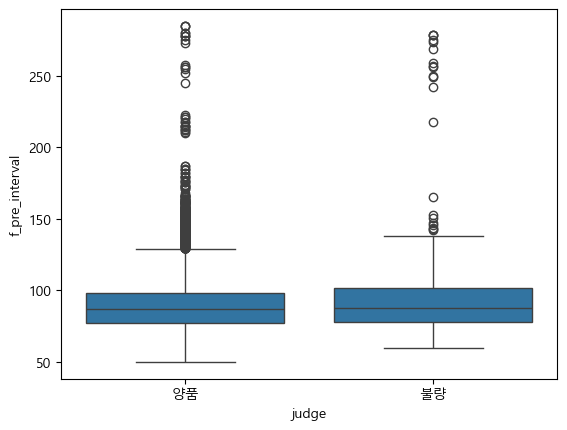

In [ ]:
sns.boxplot(y='f_pre_interval', x= 'judge', data=final_df)

<Axes: xlabel='judge', ylabel='heat_pre_diff'>

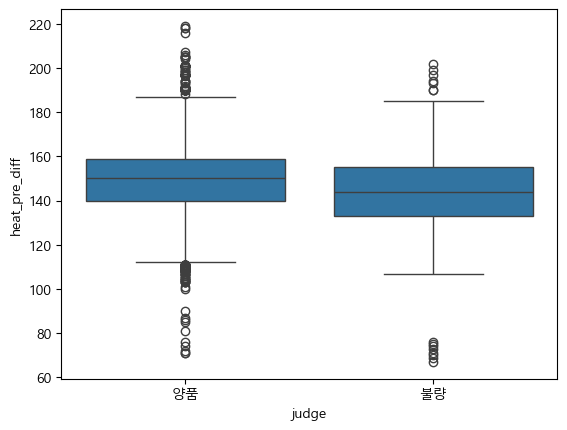

In [ ]:
sns.boxplot(y='heat_pre_diff', x= 'judge', data=final_df)

<Axes: xlabel='judge', ylabel='f_pre_temp'>

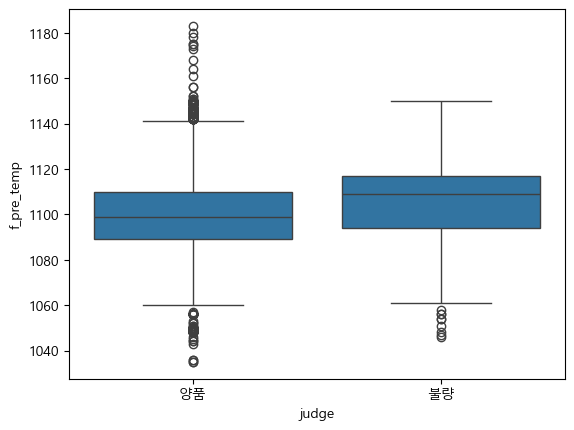

In [40]:
sns.boxplot(y='f_pre_temp', x= 'judge', data=final_df)

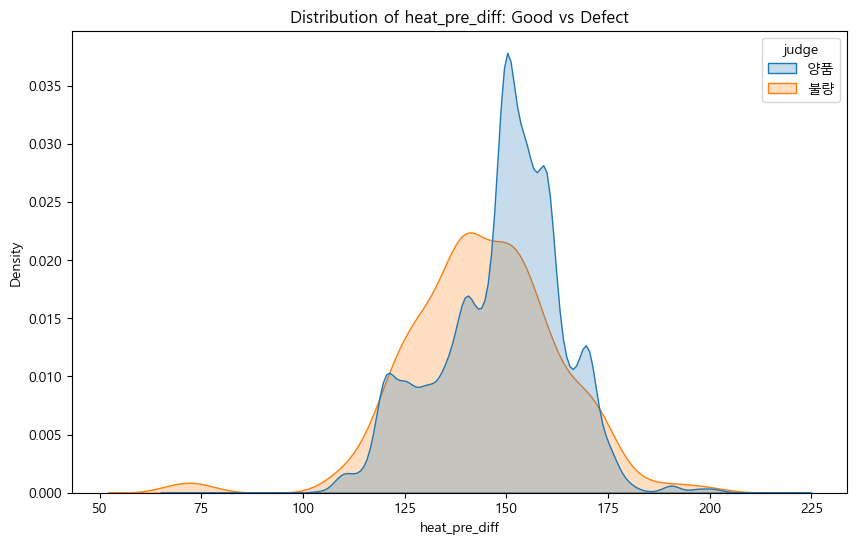

In [ ]:
plt.figure(figsize=(10, 6))
# common_norm=False를 써야 개수 차이에 상관없이 모양 비교가 가능합니다.
sns.kdeplot(data=final_df, x='heat_pre_diff', hue='judge', fill=True, common_norm=False)

plt.title('Distribution of heat_pre_diff: Good vs Defect')
plt.xlabel('heat_pre_diff')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. 구간(Bin) 설정: 5초 단위로 변경 (40초부터 310초까지)
# 5단위로 끊기 위해 step을 5로 설정합니다.
bins = np.arange(40, 315, 10) 
labels = [f"{i}-{i+10}" for i in bins[:-1]]

# 2. 구간 데이터 생성 (데이터프레임 명칭을 final_df로 유지)
final_df['interval_range'] = pd.cut(final_df['heat_pre_diff'], bins=bins, labels=labels)

# 3. 구간별 통계량 집계
# 'judge' 컬럼의 '양품', '불량' 값을 기반으로 피벗 테이블 생성
summary_table = final_df.groupby('interval_range', observed=True)['judge'].value_counts().unstack(fill_value=0)

# 4. 필수 컬럼이 없을 경우를 대비해 컬럼 보정 (양품/불량이 아예 없는 구간 방지)
for col in ['양품', '불량']:
    if col not in summary_table.columns:
        summary_table[col] = 0

# 5. 수치 계산: 전체생산량 및 불량률(%)
summary_table['전체'] = summary_table['양품'] + summary_table['불량']
summary_table['불량률(%)'] = (summary_table['불량'] / summary_table['전체'] * 100).round(2)

# 6. 신뢰도 평가: 생산 개수가 5개 미만인 구간 표시
low_sample_count = 5
summary_table['신뢰도'] = np.where(summary_table['전체'] < low_sample_count, '낮음(모수부족)', '보통')

# 7. 정리 및 출력
summary_table = summary_table[['전체', '양품', '불량', '불량률(%)', '신뢰도']]
summary_table = summary_table[summary_table['전체'] > 0] # 생산 실적이 있는 구간만 표시

print("### [5초 단위] heat_pre_diff 상세 구간별 생산 및 불량 현황 ###")
print(summary_table)

### [5초 단위] heat_pre_diff 상세 구간별 생산 및 불량 현황 ###
judge             전체    양품   불량  불량률(%)       신뢰도
interval_range                                   
60-70              3     0    3  100.00  낮음(모수부족)
70-80             10     5    5   50.00        보통
80-90              5     5    0    0.00        보통
90-100             1     1    0    0.00  낮음(모수부족)
100-110          158   152    6    3.80        보통
110-120         1021   990   31    3.04        보통
120-130         2287  2190   97    4.24        보통
130-140         3033  2907  126    4.15        보통
140-150         5706  5567  139    2.44        보통
150-160         7064  6945  119    1.68        보통
160-170         3197  3136   61    1.91        보통
170-180          952   921   31    3.26        보통
180-190           71    65    6    8.45        보통
190-200           81    77    4    4.94        보통
200-210           39    38    1    2.56        보통
210-220            4     4    0    0.00  낮음(모수부족)


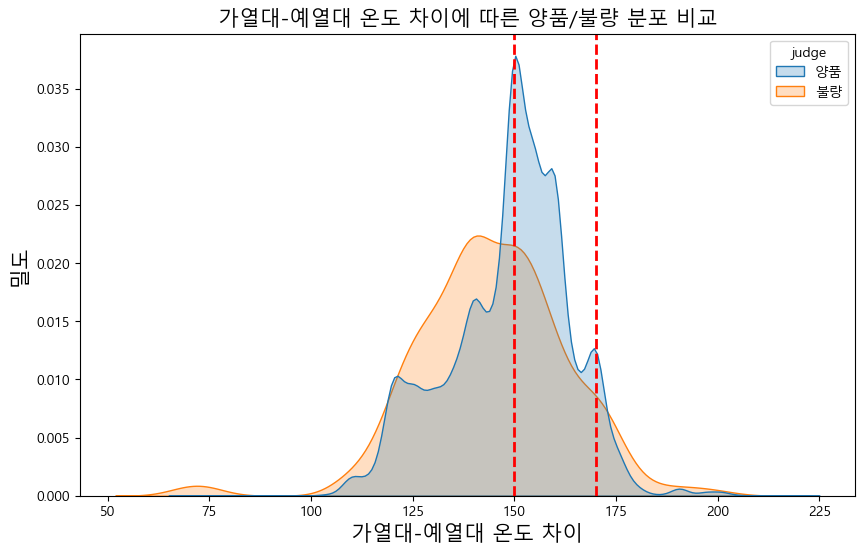

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# judge별로 색상을 나누어 밀도 함수 그리기
# common_norm=False를 설정해야 각 그룹의 전체 합을 1로 계산하여 분포 모양 비교가 쉬워집니다.
sns.kdeplot(data=final_df, x='heat_pre_diff', hue='judge', fill=True, common_norm=False)
plt.axvline(x=150, color='red', linestyle='--', linewidth=2)
plt.axvline(x=170, color='red', linestyle='--', linewidth=2)

plt.title('가열대-예열대 온도 차이에 따른 양품/불량 분포 비교', fontsize=15)
plt.xlabel('가열대-예열대 온도 차이', fontsize=15)
plt.ylabel('밀도', fontsize=15)
# plt.xlim(75, 200)
# plt.ylim(0, 0.035)

plt.show()